# AL-RNN

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd

ROOT = Path.cwd()
for path in [ROOT, ROOT / "training", ROOT / "evaluation"]:
    path_str = str(path.resolve())
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from training.alrnn_model import AL_RNN, train_sh
from training.dataset3d import TimeSeriesDataset
from evaluation.alrnn_eval_utils import load_eval_context, load_dataset, unnormalize, predict_one_step, load_model
from evaluation.trajectory_reconstruction import trajectory_reconstruction_analysis, predict_n_step
from evaluation.flow_geometry import flow_geometry_analysis
from evaluation.transition_probability import (
    transition_probability_analysis,
    used_subregion_analysis
)
from evaluation.fixed_point_stability import fixed_point_stability_analysis
from evaluation.test_long_rollout import test_long_rollout_analysis
from evaluation.policy_validity import policy_validity_analysis
from evaluation.rps_polar_geometry import polar_geometry_analysis

## 1. Matching Pennies Experiment

In this experiment, we would like to construct a dataset of mixed policy in matching pennies game, in order to test if ALRNN model can reconstruct the dynamical behavior policy of 2 players.

Matching pennies is a 2-player zero-sum game, the two players each choose either Heads or Tails. Player 1 wants both players to make the same choice, while Player 2 wants both players to make different choices.

It is easy to write down the payoff matrix of player 1:
$$
A =
\begin{array}{c|cc}
    & H & T \\
    \hline
    H & 1 & -1 \\
    T & -1 & 1 \\
\end{array}
$$
The rows represent the actions of player 1, and the columns represent the actions of player 2.

Because this game is a zero-sum game, so the payoff matrix of player 2 should be $B = -A$.

In this game, we assume that the probability of player 1 choosing heads is $p_1$ and the probability of player 2 choosing heads is $p_2$. So the mixed policy should be:

$$[\pi_1=\begin{pmatrix}
p_1,\
1-p_1
\end{pmatrix}\qquad
\pi_2=\begin{pmatrix}
p_2,\
1-p_2
\end{pmatrix}]$$

And the mixed nash equilibruim of matching pennies game shoud be
$$[
\pi^*=
\begin{pmatrix}
0.5\
0.5
\end{pmatrix}
]$$

The expected payoff of player 1 equals:
$$
U_1(p_1, p_2) = p_1 p_2 - p_1 (1 - p_2) - (1 - p_1) p_2 + (1 - p_1)(1 - p_2) = (2p_1 - 1)(2p_2 - 1)
$$
And $U_2(p_1, p_2) = - U_1(p_1, p_2)$.

Therefore, using gradient learning rule, we can obtain a dynamic system equation:
$$
\frac{dp_1}{dt} = \frac{\partial U_1}{\partial p_1} = 2(2p_2 - 1) = 4(p_2 - \frac{1}{2})
$$
and
$$
\frac{dp_2}{dt} = - 4(p_1 - \frac{1}{2})
$$

In the experiment, instead of using the original probabilities directly, we use the centralized states relative to the mixture Nash equilibrium, so the policy vector is
$$
\begin{pmatrix}
p_1-\frac12,\
p_2-\frac12
\end{pmatrix}
$$

Set $x_1 = p_1 - \frac{1}{2}$, $x_2 = p_2 - \frac{1}{2}$, we can get the unconstrained dynamics of the strategy pair as a function of time is defined by the following differential equation
$$
\frac{d}{dt} \begin{pmatrix} x_1 \\ x_2 \end{pmatrix} = \begin{pmatrix} 0 & 4 \\ -4 & 0 \end{pmatrix} \begin{pmatrix} x_{1,t} \\ x_{2,t} \end{pmatrix}
$$

In the code, we use rotation angles to construct the trajectory. And finally, the standardized datasets were used for the experiment.

### Dataset import and visualisation

In [2]:
MP_DATA_DIR = Path("datasets/MP_data")
MP_MODEL_PATH = Path("models/mp_1.pt")

mp_data = load_dataset(MP_DATA_DIR)
mp_metadata = mp_data["metadata"]
mp_train_norm = mp_data["train_norm"]
mp_test_norm = mp_data["test_norm"]
mp_train_raw = mp_data["train_raw"]
mp_test_raw = mp_data["test_raw"]

In [3]:
mp_train_flat = mp_train_raw.reshape(-1, mp_train_raw.shape[-1])
mp_test_flat = mp_test_raw.reshape(-1, mp_test_raw.shape[-1])

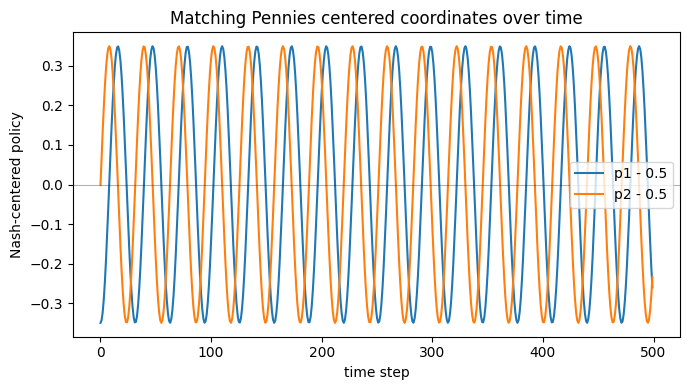

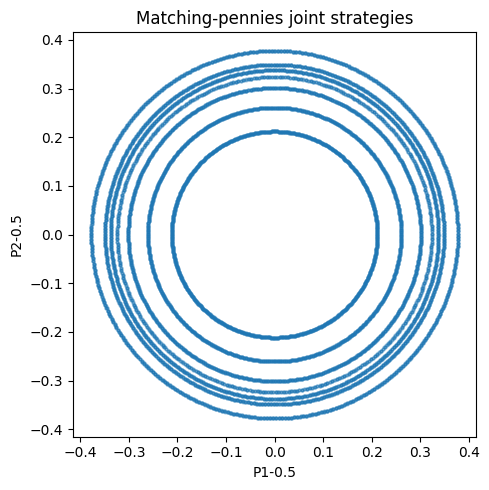

In [4]:
# view of one MP trajectory
traj = mp_train_raw[0]
plt.figure(figsize=(7, 4))
plt.plot(traj[:500, 0], label="p1 - 0.5")
plt.plot(traj[:500, 1], label="p2 - 0.5")
plt.axhline(0.0, color="black", linewidth=0.8, alpha=0.3)
plt.xlabel("time step")
plt.ylabel("Nash-centered policy")
plt.title("Matching Pennies centered coordinates over time")
plt.legend()
plt.tight_layout()
plt.show()

# Simple phase portrait
plt.figure(figsize=(5, 5))
plt.scatter(mp_train_flat[:10000, 0], mp_train_flat[:10000, 1], s=4, alpha=0.35)
plt.xlabel("P1-0.5")
plt.ylabel("P2-0.5")
plt.title("Matching-pennies joint strategies")
plt.tight_layout()
plt.show()


### MP Training

In [5]:
def train_current_model(train_norm, model_path, config):
    torch.manual_seed(config["seed"])
    np.random.seed(config["seed"])

    N = train_norm.shape[-1]
    model = AL_RNN(M=config["M"], P=config["P"], N=N)
    dataset = TimeSeriesDataset(
        train_norm,
        sequence_length=config["sequence_length"],
        batch_size=config["batch_size"],
    )

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.RAdam(model.parameters(), lr=config["start_learning_rate"])
    gamma = (config["end_learning_rate"] / config["start_learning_rate"]) ** (1 / config["num_epochs"])
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

    metrics = train_sh(
        model,
        dataset,
        optimizer,
        scheduler,
        loss_fn,
        num_epochs=config["num_epochs"],
        alpha=config["alpha"],
        n_interleave=config["n_interleave"],
        batches_per_epoch=config["batches_per_epoch"],
        ssi=25,
    )

    model_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), model_path)
    np.save(model_path.with_suffix(".losses.npy"), np.asarray(metrics[0], dtype=np.float32))

    return model, metrics

In [8]:
MP_TRAIN_CONFIG = {
    "M": 12,
    "P": 1,
    "num_epochs": 500,
    "batches_per_epoch": 50,
    "sequence_length": 200,
    "batch_size": 16,
    "alpha": 1,
    "n_interleave": 16,
    "start_learning_rate": 1e-3,
    "end_learning_rate": 1e-5,
    "seed": 11,
}

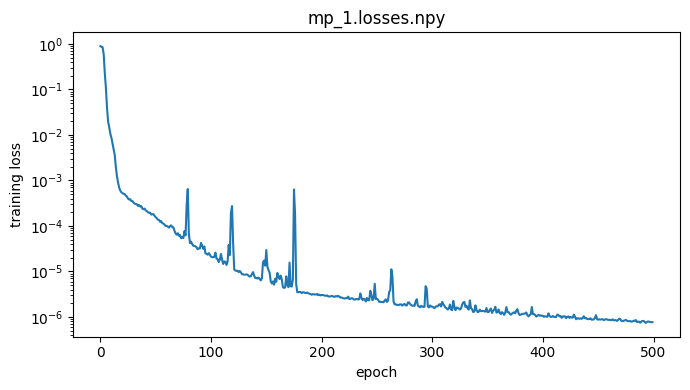

In [9]:
#mp_model, mp_train_metrics = train_current_model(mp_train_norm, model_path=MP_MODEL_PATH, config=MP_TRAIN_CONFIG)

loss_path = MP_MODEL_PATH.with_suffix(".losses.npy")

if loss_path.exists():
    losses = np.load(loss_path)
    plt.figure(figsize=(7, 4))
    plt.plot(losses)
    plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel("training loss")
    plt.title(loss_path.name)
    plt.tight_layout()
    plt.show()
else:
    print("No saved loss file:", loss_path)

The loss of matching pennies experiment eventually becomes very small and tends to stabilise (approximatly $10e^{-6}$), which suggests that ALRNN has learned a relatively good dynamic structure. However, several peaks shown in the loss curve, that could be explained as temporary optimisation instability.

### MP Model Analysis

#### MSE

In [10]:
mp_ctx = load_eval_context(
    MP_DATA_DIR,
    MP_MODEL_PATH,
    M=MP_TRAIN_CONFIG["M"],
    P=MP_TRAIN_CONFIG["P"],
)

mp_trajectory = trajectory_reconstruction_analysis(
    mp_ctx,
    n_rollout=4,
    steps=500,
    prediction_horizon=10,
    n_bins=20,
    smoothing=20,
    #plot=True,
)
mp_rollout = mp_trajectory["rollout"]

print("MP one-step mse:", round(mp_trajectory["one_step_mse"], 6))
print("MP n-step horizon:", mp_trajectory["prediction_horizon"])
print("MP n-step mse:", round(mp_trajectory["n_step_mse"], 6))
print("MP rollout mse:", round(mp_trajectory["rollout_mse"], 6))
print("MP attractor metrics:", mp_trajectory["attractor_metrics"])


MP one-step mse: 0.000151
MP n-step horizon: 10
MP n-step mse: 1.4e-05
MP rollout mse: 0.007469
MP attractor metrics: {'state_space_divergence': 0.702763, 'power_spectrum_error_mean': 0.001849, 'power_spectrum_error_std': 0.000585}


/Users/haofangfan/Downloads/thesis_haofang/ALRNN-DSR/alrnn_python/training/metrics.py:31: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:656.)
  return tens(coordinates.t(), indices, size=size_).to_dense()


We evaluate the learned ALRNN model on matching pennies trajectory dataset:

- one-stpe mse means short term predict ability ($x_t \rightarrow x_{t+1}$): Here, mse is around 0.0002, which represents that the model has learned the local transition rule of the system very well.

- n-step mse (here, n=10) $\approx 0$, it can be explained as the predict ability from $x_t$ to $x_{t+10}$, the low value suggests that the model captures the short-term rotational structure of the matching pennies dynamics.

- Rollout mse (here, steps=500) evaluates long-term autonomous prediction ($x_t \rightarrow x_{t+steps}$). This value is much larger than the one-step error and the n-step error. This result is understandable for periodic rotating systems. Even if the local errors of the model are small, tiny errors in the learned rotation angles, radius preservation, or phase evolution will accumulate over hundreds of iterations.

- state space divergence $\approx 0.7$: This value indicates a slight difference between the long-term distribution of the generated policy and the true state distribution. In the matching coin system, the true attractor is a closed circular orbit around the Nash equilibrium. A higher state space divergence suggests that the trajectory generated by the model may not perfectly match the geometry of the true orbit. 

- power spectrum error mean=0.001849 with std=0.000585 indicates that the model captures the dominant temporal frequency of the matching pennies dynamics quite well.

#### Phase portrait (generated trajectory)

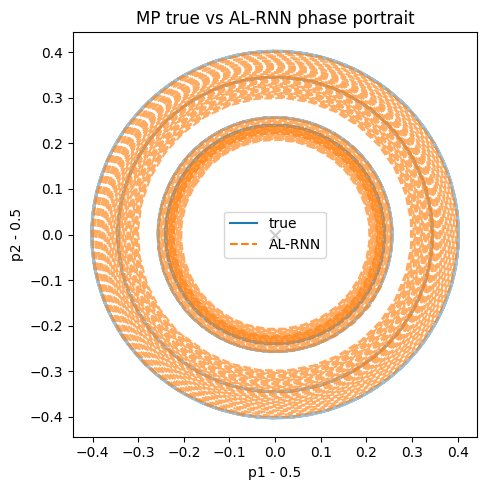

In [11]:
# true trajectories and AL-RNN rollouts in Nash-centered raw space.
true = mp_rollout["target_raw"]
pred = mp_rollout["pred_raw"]

plt.figure(figsize=(5, 5))
for k in range(len(true)):
    plt.plot(true[k, :, 0], true[k, :, 1], color="C0", alpha=0.45)
    plt.plot(pred[k, :, 0], pred[k, :, 1], color="C1", linestyle="--", alpha=0.65)

plt.scatter([0.0], [0.0], color="black", marker="x", s=60)
lim = 1.1 * max(np.max(np.abs(true)), np.max(np.abs(pred)), 1e-3)
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("p1 - 0.5")
plt.ylabel("p2 - 0.5")
plt.title("MP true vs AL-RNN phase portrait")
plt.plot([], [], color="C0", label="true")
plt.plot([], [], color="C1", linestyle="--", label="AL-RNN")
plt.legend()
plt.tight_layout()
plt.show()



This is the phase portrait of ground truth dataset and the generated trajectories of the model, it shows that the trajectory generated by ALRNN exhibits some drift, resulting in a wide orange trajectory. This confirms the large state space divergence value, indicating a certain degree of geometrical deviation in long-term trajectory reconstruction.

#### Transition probability

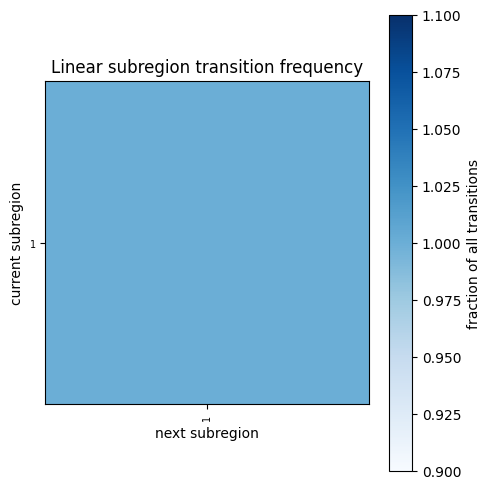

MP used subregions: 1 / 2
MP region labels:
['1']
MP region frequencies:
[2000.]
MP transition connectome shape: (1, 1)
MP transition connectome sum: 1.0
MP transition connectome:
[[1.]]


In [12]:
mp_used = used_subregion_analysis(mp_rollout["latent"], P=MP_TRAIN_CONFIG["P"])
mp_transition = transition_probability_analysis(
    mp_rollout["latent"],
    P=MP_TRAIN_CONFIG["P"],
    plot=True,
)

print("MP used subregions:", mp_used["num_used_subregions"], "/", mp_used["total_possible_subregions"])
print("MP region labels:")
print(mp_used["region_labels"])
print("MP region frequencies:")
print(mp_used["region_frequencies"])
print("MP transition connectome shape:", mp_transition["connectome"].shape)
print("MP transition connectome sum:", float(np.nansum(mp_transition["connectome"])))
print("MP transition connectome:")
print(mp_transition["connectome"])


We can conclude from the result that in this matching pennies experiment, dynamics learned by ALRNN do not have subregion switching, all states stay within the same linear subregion, thus the model can describe the entire trajectory using a single local linear dynamic. In other words, the dynamics of matching pennies can be explained by a stable linear rotational mode, which is consistent with our generation mechanism.

#### Fixed point stability

In [45]:
#fixed_point_mp = fixed_point_stability_analysis(mp_ctx, steps=2500, lr=1e-3, tol=1e-2, plot=True,)

In [46]:
#fixed_point_mp

To further analyze whether AL-RNN has learned the main dynamics of matching pennies, we examine the fixed point learned by the model and its local stability.  

To find the fixed point of the model, we use different initial starts to run the trajectory and look for the point with minimum residual of true fixed point. 

For matching pennies data, the real dynamic system is a rotating system around a Nash equilibrium. In centered coordinates, the real fixed point is located at the origin $(0, 0)$, which is the nash equilibrium in the original coordinate space $(\frac{1}{2}, \frac{1}{2})$.

From the result, we can get the fixed point of the model in the standrised space $(-0.0582, -0.0639)$, mapping it back to the original centralized state space is $x_{recon}^*(-0.0134, -0.0145)$. The true fixed point is $x^*=(0, 0)$, so the distance between $x_{recon}^*$ and $x^*$ is about $0.0197$. The distance is small, so we can say that the learned fixed point is very close to the true mixed nash equilibrium.

The function of fixed point is $F(x_t) = x_{t+1} = x_t$, so the residual mse of fixed point is the mse of $F(x^*) - x^*$. We can also compute the local Jacobian and eigenvalues around fixed point, the result of eigenvaluea is $[0.9729924+0.19999442j, 0.9729924-0.19999442j]$, the maximum mod of it is approximate 0.9933, even though it is not 1, but the error is less than 0.01, we can say that the model learns a fixed point very close to the true fixed point.

## 2. Rock Paper Scissors-WoLF algorithm Experiment


The experiment we do here is trying to find out if ALRNN model can reconstruct behavior portrait of a rock-paper-scissors game dataset simulated from a WoLF-PHC algorithm.

Win or learn fast with policy hill climbing algorithm (WoLF-PHC): In this algorithm, players update their policy depend on not only current action value function $Q$, but also adjust learning rate based on "winning" or "losing" currently.

If the current policy performs better than the average policy, it is considered to be "winning" and is updated cautiously with a smaller step size; if the current policy performs worse than the average policy, it is considered to be "losing" and is adjusted quickly with a larger step size.

For each player $i$, WoLF-PHC maintains three main quantities: action value function $Q_i$, current policy $\pi_i(a_i|s)$ and average policy $\bar{\pi}_i$.

After interacting with the environment and the other players, it receives a reward $r_i^t$ and observes the next state $s^{t+1}$. The action-value function is then updated
$$Q(s^t, a_i^t) \leftarrow Q(s^t, a_i^t)+ \alpha [r_i^t + \gamma max_{a_i'}Q_i(s^{t+1}, a_i') - Q(s^t, a_i^t)]$$

Next, the algorithm updates the average policy $\bar{\pi}_i$:
$$ C(s^t) \leftarrow C(s^t) + 1$$

$$ \bar{\pi_i}(a_i | s^t)  \leftarrow \bar{\pi_i}(a_i | s^t) + \frac{1}{C(s^t)} (\pi_i(a_i | s^t) - \bar{\pi_i}(a_i | s^t))$$
where $C(s^t)$ is state count.

Then the player compares the expected value of its current policy with the expected value of its average policy. The value of the current policy is:
$$ \sum_{a_i'}\pi_i(a_i'|s)Q_i(s, a_i')$$
while the value of the average policy is:
$$ \sum_{a_i'}\bar{\pi_i}(a_i'|s)Q_i(s, a_i')$$

If the value of the current policy > the value of the average policy, then the player is considered to be winning and uses a smaller policy learning rate $\delta = l_w$ ,otherwise $\delta = l_l$.

Finally, WoLF-PHC performs a policy hill-climbing update and update policy is:
$$\pi_i(a_i|s^t) \leftarrow \pi_i(a_i|s^t)  + \Delta(s^t, a_i)$$

with the definiton: $ ∆(s, a_i) = \delta_{s, a_i}$ if $a_i \notin argmax_{a_i'}Q(s, a_i')$; otherwise, $ ∆(s, a_i) = \sum_{a_i' \neq a_i}\delta_{s, a_i'}$. Where, $\delta_{s, a_i}$ = min($\pi_i(a_i|s)$, $\frac{\delta}{|A_i| - 1}$).

In our experiment, we use the mixed observation as input of model ALRNN, and to simplify, we remove the simplex redundancy and center the mixed Nash equilibrium at the origin.

### Dataset import and visualisation

In [40]:
WOLF_DATA_DIR = Path("datasets/WoLF_4D_data_new")
WOLF_MODEL_PATH = Path("models/WoLF_2")

wolf_data = load_dataset(WOLF_DATA_DIR)
wolf_metadata = wolf_data["metadata"]
wolf_train_norm = wolf_data["train_norm"]
wolf_test_norm = wolf_data["test_norm"]
wolf_train_raw = wolf_data["train_raw"]
wolf_test_raw = wolf_data["test_raw"]

wolf_train_full = np.load(WOLF_DATA_DIR / "train_full.npy")
wolf_test_full = np.load(WOLF_DATA_DIR / "test_full.npy")

print("train norm shape:", wolf_train_norm.shape)
print("test norm shape:", wolf_test_norm.shape)
print("train raw shape:", wolf_train_raw.shape)
print("test raw shape:", wolf_test_raw.shape)
print("train full shape:", wolf_train_full.shape)
print("test full shape:", wolf_test_full.shape)


train norm shape: (160, 3000, 4)
test norm shape: (40, 3000, 4)
train raw shape: (160, 3000, 4)
test raw shape: (40, 3000, 4)
train full shape: (160, 3000, 6)
test full shape: (40, 3000, 6)


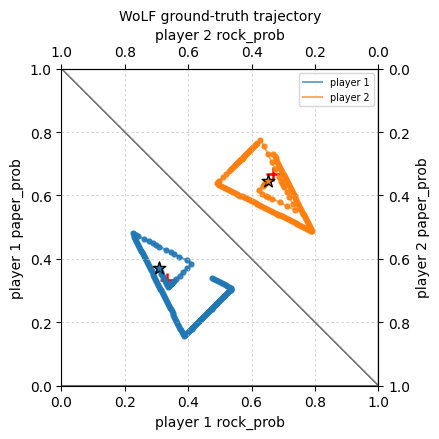

In [41]:
def plot_simplex_axes(ax):
    ticks = np.arange(0, 1.01, 0.2)

    ax.plot([0, 1, 0, 0], [0, 0, 1, 0], color="0.45", linewidth=0.9)
    ax.plot([1, 0, 1, 1], [1, 1, 0, 1], color="0.45", linewidth=0.9)

    ax.plot([0, 1], [1, 0], linestyle=(0, (3, 3)), color="0.45", linewidth=0.8)

    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.grid(True, linestyle=(0, (3, 3)), linewidth=0.6, color="0.75", alpha=0.8,)

    # Nash equilibrium
    ax.scatter(1 / 3, 1 / 3, marker="+", s=90, color="red", linewidth=1.8)
    ax.scatter(2 / 3, 2 / 3, marker="+", s=90, color="red", linewidth=1.8)


def plot_simplex(trajectory_full_6d, max_steps=800, stride=20):
    policy = trajectory_full_6d[:max_steps]
    idx = np.arange(0, len(policy), stride)

    p1 = policy[:, :3]
    p2 = policy[:, 3:]

    p1_xy = np.column_stack([p1[:, 0], p1[:, 1]])
    p2_xy = np.column_stack([1.0 - p2[:, 0], 1.0 - p2[:, 1]])

    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    plot_simplex_axes(ax)

    ax.plot(p1_xy[:, 0], p1_xy[:, 1], color="C0", linewidth=1.4, alpha=0.65, label="player 1",)
    ax.plot(p2_xy[:, 0], p2_xy[:, 1], color="C1", linewidth=1.4, alpha=0.65, label="player 2",)

    ax.scatter(p1_xy[idx, 0], p1_xy[idx, 1], color="C0", s=12, alpha=0.85)
    ax.scatter(p2_xy[idx, 0], p2_xy[idx, 1], color="C1", s=12, alpha=0.85)

    ax.scatter(p1_xy[-1, 0], p1_xy[-1, 1], color="C0", marker="*", s=90, edgecolors="black")
    ax.scatter(p2_xy[-1, 0], p2_xy[-1, 1], color="C1", marker="*", s=90, edgecolors="black",)

    ticks = np.arange(0, 1.01, 0.2)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("player 1 rock_prob")
    ax.set_ylabel("player 1 paper_prob")

    secax_x = ax.secondary_xaxis(
        "top",
        functions=(lambda x: 1.0 - x, lambda x: 1.0 - x),
    )
    secax_y = ax.secondary_yaxis(
        "right",
        functions=(lambda y: 1.0 - y, lambda y: 1.0 - y),
    )

    secax_x.set_xticks(ticks)
    secax_y.set_yticks(ticks)
    secax_x.set_xlabel("player 2 rock_prob")
    secax_y.set_ylabel("player 2 paper_prob")

    ax.set_title("WoLF ground-truth trajectory", fontsize=10)
    ax.legend(fontsize="x-small", loc="best")

    fig.tight_layout()
    plt.show()


WOLF_EXAMPLE_IDX = 10
plot_simplex(wolf_train_full[WOLF_EXAMPLE_IDX], max_steps=3000, stride=20)


We randomly choose 1 ground truth trajectory from the training datasets and see if the trajectory converge to the nash equilibrium.

### WoLF RPS Model Training

In [42]:
WOLF_TRAIN_CONFIG = {
    "M": 64,
    "P": 4,
    "num_epochs": 1000,
    "batches_per_epoch": 50,
    "sequence_length": 600,
    "batch_size": 18,
    "alpha": 0.7,
    "n_interleave": 96,
    "start_learning_rate": 1e-3,
    "end_learning_rate": 1e-5,
    "seed": 23,
}

In [ ]:
#wolf_model, wolf_train_metrics = train_current_model(wolf_train_norm, model_path=WOLF_MODEL_PATH, config=WOLF_TRAIN_CONFIG,)

Training Progress: 100%|██████████| 1000/1000 [2:03:04<00:00,  7.38s/it, loss=0.151] 


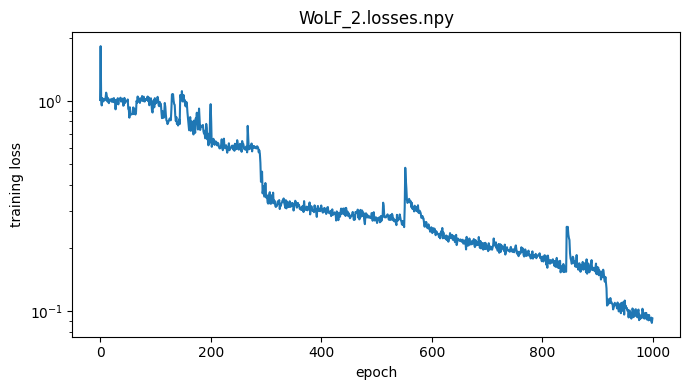

In [43]:
loss_path =WOLF_MODEL_PATH.with_suffix(".losses.npy")

if loss_path.exists():
    losses = np.load(loss_path)
    plt.figure(figsize=(7, 4))
    plt.plot(losses)
    plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel("training loss")
    plt.title(loss_path.name)
    plt.tight_layout()
    plt.show()
else:
    print("No saved loss file:", loss_path)

In [44]:
wolf_ctx = load_eval_context(
    WOLF_DATA_DIR,
    WOLF_MODEL_PATH,
    M=WOLF_TRAIN_CONFIG["M"],
    P=WOLF_TRAIN_CONFIG["P"],
)

wolf_trajectory = trajectory_reconstruction_analysis(
    wolf_ctx,
    n_rollout=40,
    steps=3000,
    prediction_horizon=10,
    n_bins=6,
    smoothing=20,
    plot=False,
)
wolf_rollout = wolf_trajectory["rollout"]

print("wolf one-step mse:", wolf_trajectory["one_step_mse"])
print("wolf one-step per-dim mse:", wolf_trajectory["one_step_per_dim_mse"])
print("wolf n-step horizon:", wolf_trajectory["prediction_horizon"])
print("wolf n-step mse:", wolf_trajectory["n_step_mse"])
print("wolf rollout mse:", wolf_trajectory["rollout_mse"])
print("wolf attractor metrics:", wolf_trajectory["attractor_metrics"])


wolf one-step mse: 0.036992
wolf one-step per-dim mse: [0.055507, 0.026794, 0.049947, 0.015715]
wolf n-step horizon: 10
wolf n-step mse: 0.270326
wolf rollout mse: 1.092536
wolf attractor metrics: {'state_space_divergence': 9.778296, 'power_spectrum_error_mean': 0.081637, 'power_spectrum_error_std': 0.0418}


### WoLF Reconstruction, Transition, And Fixed Point

Use the trained WoLF 4D AL-RNN rollout to inspect reconstructed policy trajectories, linear-region transitions, and fixed point stability.

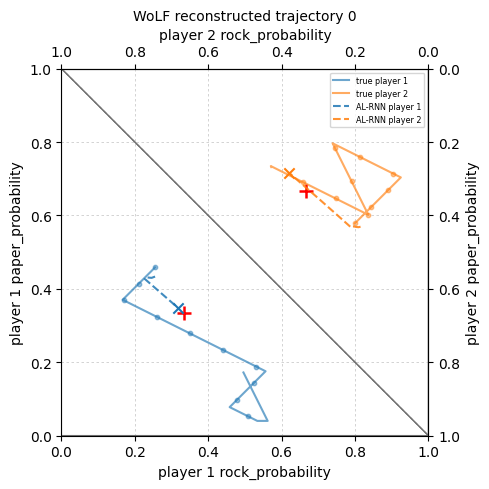

In [45]:
def wolf4d_to_full_policy(obs_4d):
    obs_4d = np.asarray(obs_4d)
    policy = np.empty(obs_4d.shape[:-1] + (6,), dtype=obs_4d.dtype)
    policy[..., 0] = obs_4d[..., 0] + 1 / 3
    policy[..., 1] = obs_4d[..., 1] + 1 / 3
    policy[..., 2] = 1.0 - policy[..., 0] - policy[..., 1]
    policy[..., 3] = obs_4d[..., 2] + 1 / 3
    policy[..., 4] = obs_4d[..., 3] + 1 / 3
    policy[..., 5] = 1.0 - policy[..., 3] - policy[..., 4]
    return policy


def plot_wolf_reconstruction_simplex(wolf_rollout, trajectory_idx=0, max_steps=1000, stride=25):
    true_4d = wolf_rollout["target_raw"][trajectory_idx, :max_steps]
    pred_4d = wolf_rollout["pred_raw"][trajectory_idx, :max_steps]
    true_full = wolf4d_to_full_policy(true_4d)
    pred_full = wolf4d_to_full_policy(pred_4d)
    idx = np.arange(0, len(true_full), stride)

    true_p1 = np.column_stack([true_full[:, 0], true_full[:, 1]])
    true_p2 = np.column_stack([1.0 - true_full[:, 3], 1.0 - true_full[:, 4]])
    pred_p1 = np.column_stack([pred_full[:, 0], pred_full[:, 1]])
    pred_p2 = np.column_stack([1.0 - pred_full[:, 3], 1.0 - pred_full[:, 4]])

    fig, ax = plt.subplots(figsize=(5, 5))
    plot_simplex_axes(ax)

    ax.plot(true_p1[:, 0], true_p1[:, 1], color="C0", linewidth=1.5, alpha=0.65, label="true player 1")
    ax.plot(true_p2[:, 0], true_p2[:, 1], color="C1", linewidth=1.5, alpha=0.65, label="true player 2")
    ax.plot(pred_p1[:, 0], pred_p1[:, 1], color="C0", linestyle="--", linewidth=1.5, alpha=0.85, label="AL-RNN player 1")
    ax.plot(pred_p2[:, 0], pred_p2[:, 1], color="C1", linestyle="--", linewidth=1.5, alpha=0.85, label="AL-RNN player 2")

    ax.scatter(true_p1[idx, 0], true_p1[idx, 1], color="C0", s=10, alpha=0.45)
    ax.scatter(true_p2[idx, 0], true_p2[idx, 1], color="C1", s=10, alpha=0.45)
    ax.scatter(pred_p1[-1, 0], pred_p1[-1, 1], color="C0", marker="x", s=55)
    ax.scatter(pred_p2[-1, 0], pred_p2[-1, 1], color="C1", marker="x", s=55)

    ticks = np.arange(0, 1.01, 0.2)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("player 1 rock_probability")
    ax.set_ylabel("player 1 paper_probability")

    secax_x = ax.secondary_xaxis("top", functions=(lambda x: 1.0 - x, lambda x: 1.0 - x))
    secax_y = ax.secondary_yaxis("right", functions=(lambda y: 1.0 - y, lambda y: 1.0 - y))
    secax_x.set_xticks(ticks)
    secax_y.set_yticks(ticks)
    secax_x.set_xlabel("player 2 rock_probability")
    secax_y.set_ylabel("player 2 paper_probability")

    ax.set_title(f"WoLF reconstructed trajectory {wolf_rollout['trajectory_indices'][trajectory_idx]}", fontsize=10)
    ax.legend(fontsize="xx-small", loc="best")
    fig.tight_layout()
    plt.show()


plot_wolf_reconstruction_simplex(wolf_rollout, trajectory_idx=0, max_steps=3000, stride=300)

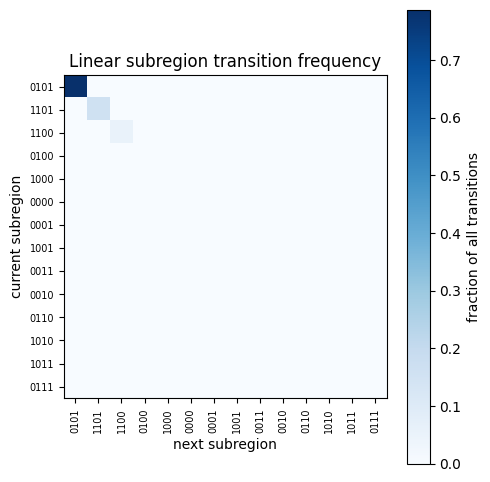

WoLF used subregions: 14 / 16
WoLF region labels:
['0101', '1101', '1100', '0100', '1000', '0000', '0001', '1001', '0011', '0010', '0110', '1010', '1011', '0111']
WoLF region frequencies:
[9.4428e+04 1.8931e+04 6.5360e+03 1.4000e+01 1.1000e+01 1.1000e+01
 1.0000e+01 4.0000e+00 4.0000e+00 4.0000e+00 3.0000e+00 2.0000e+00
 1.0000e+00 1.0000e+00]
WoLF transition connectome shape: (14, 14)
WoLF transition connectome sum: 1.0
WoLF row-stochastic transition shape: (14, 14)


In [46]:
wolf_used = used_subregion_analysis(wolf_rollout["latent"], P=WOLF_TRAIN_CONFIG["P"])
wolf_transition = transition_probability_analysis(
    wolf_rollout["latent"],
    P=WOLF_TRAIN_CONFIG["P"],
    plot=True,
)

print("WoLF used subregions:", wolf_used["num_used_subregions"], "/", wolf_used["total_possible_subregions"])
print("WoLF region labels:")
print(wolf_used["region_labels"])
print("WoLF region frequencies:")
print(wolf_used["region_frequencies"])
print("WoLF transition connectome shape:", wolf_transition["connectome"].shape)
print("WoLF transition connectome sum:", float(np.nansum(wolf_transition["connectome"])))
print("WoLF row-stochastic transition shape:", wolf_transition["row_stochastic_transition"].shape)

In [47]:
wolf_all_test_rollout = test_long_rollout_analysis(
    wolf_ctx,
    n_bins=6,
    smoothing=20,
)
wolf_policy_validity = policy_validity_analysis(
    wolf_ctx,
    tol=1e-6,
)

wolf_all_test_rollout_table = pd.DataFrame(
    [
        {
            "n_test_rollouts": wolf_all_test_rollout["n_test_rollouts"],
            "steps": wolf_all_test_rollout["steps"],
            "mean_rollout_mse": wolf_all_test_rollout["mean_rollout_mse"],
            "median_rollout_mse": wolf_all_test_rollout["median_rollout_mse"],
            "worst_rollout_mse": wolf_all_test_rollout["worst_rollout_mse"],
            "state_space_divergence": wolf_all_test_rollout["state_space_divergence"],
            "power_spectrum_error_mean": wolf_all_test_rollout["power_spectrum_error_mean"],
            "power_spectrum_error_std": wolf_all_test_rollout["power_spectrum_error_std"],
        }
    ]
)

wolf_policy_validity_table = pd.DataFrame(
    [
        {
            "n_test_rollouts": wolf_policy_validity["n_test_rollouts"],
            "steps": wolf_policy_validity["steps"],
            "n_invalid_pred_rollouts": wolf_policy_validity["n_invalid_pred_rollouts"],
            "invalid_pred_rollout_fraction": wolf_policy_validity["invalid_pred_rollout_fraction"],
            "min_pred_probability": wolf_policy_validity["min_pred_probability"],
            "max_pred_probability": wolf_policy_validity["max_pred_probability"],
        }
    ]
)

display(
    wolf_all_test_rollout_table.style.format(
        {
            "mean_rollout_mse": "{:.6g}",
            "median_rollout_mse": "{:.6g}",
            "worst_rollout_mse": "{:.6g}",
            "state_space_divergence": "{:.6g}",
            "power_spectrum_error_mean": "{:.6g}",
            "power_spectrum_error_std": "{:.6g}",
        }
    )
)

display(
    wolf_policy_validity_table.style.format(
        {
            "invalid_pred_rollout_fraction": "{:.6g}",
            "min_pred_probability": "{:.6g}",
            "max_pred_probability": "{:.6g}",
            "max_pred_sum_error": "{:.6g}",
        }
    )
)


,n_test_rollouts,steps,mean_rollout_mse,median_rollout_mse,worst_rollout_mse,state_space_divergence,power_spectrum_error_mean,power_spectrum_error_std
0,40,2999,1.09254,0.923529,3.00961,9.7783,0.0816366,0.0418002


,n_test_rollouts,steps,n_invalid_pred_rollouts,invalid_pred_rollout_fraction,min_pred_probability,max_pred_probability
0,40,2999,0,0,0.142332,0.541075


## Modifications made from June 29, 2026, to July 2, 2026:

- First, I checked whether the trajectories generated by the previous WoLF-ALRNN model were invalid. The results showed that all trajectories in the test datasets were indeed invalid(totally 20 trajectories). Based on this, I explored potential improvements. To ensure our simulation experiments remain clean, I chose not to modify or optimize the ALRNN model architecture itself. Instead, I modified the generator to increase the volume of generated trajectories and enrich the dataset. Specifically, the training dataset was expanded to $160$ trajectories (with $T=3000$), and the test dataset was expanded to $40$ trajectories. The generated dataset is saved in `datasets/WoLF_4D_data_new`.

- When training the WoLF-ALRNN model, I appropriately reduced the number of `training epochs`. This is because excessively large training epochs cause the trajectories in the ALRNN long rollout to drift (a point I will explain in further detail in the RPS separate game section below). I set the epochs to $1000$ and prioritized the training experiments for $P=4$. The model is saved in `models/WoLF_2`.

- The experimental results indicate that all ALRNN long rollout trajectories are valid and show good error metrics. `mean_rollout_mse` = $1.09$, `median_rollout_mse` = $0.92$ and `worst_rollout_mse`= $3.01$. Moreover, `state_space_divergence` is a little large, around $9.78$ and `power_spectrum_error_mean`=$0.08$. During this process, the actual number of `subregions` used was $14$, so I am further considering experiments for $P=2$.

- When $P=2$ for WoLF-ALRNN model, all long rollout trajectories are valid and the actual number of `subregions` used was $4$. The quantitative analysis results are shown in the table. `mean_rollout_mse` = $1.03$, `median_rollout_mse` = $0.86$ and `worst_rollout_mse`= $2.54$. The MSE is low, but the dynamic structure is poor. `state_space_divergence` is around $10.43$ and `power_spectrum_error_mean`=$0.11$, the generated trajectories of the ALRNN model with $P=4$ are closer to those of the real system in terms of state-space distribution and spectral structure. The model with $P=2$ is saved in `models/WoLF_3`.

## 3. Rock Paper Scissors Experiment

In this experiment, we are trying to examine whether ALRNN model can learn different policy trajectory types. By using different parameters, we can construct data trajectories with distinct characteristics.

In a classic Rock Paper Scissors game, each player has 3 actions $A = \{R, P, S\}$, a mixed policy is a probability vector 
$\pi = \begin{pmatrix}
\pi_R \\
\pi_P \\
\pi_S
\end{pmatrix}$, where $\pi_R + \pi_P + \pi_S = 1$ and $\pi_R, \pi_P,  \pi_S >= 0$

Payoff matrix of a zero-sum rock-paper-scissors game should be:
$$
A = \begin{pmatrix}
0 & -1 & 1 \\
1 & 0 & -1 \\
-1 & 1 & 0
\end{pmatrix}$$
Rows correspond to the player1’s own actions, and columns correspond to the player2’s actions. 

So the standard Nash equilibrium is the uniform policy: $\pi^* = \begin{pmatrix}
1/3 \\
1/3 \\
1/3
\end{pmatrix}$

A more general payoff matrix allows for non-zero-sum games, the winner gets a payoff $1$ and the loser gets $-s$ can be expressed as
$$
A_{s} = \begin{pmatrix}
0 & -s & 1 \\
1 & 0 & -s \\
-s & 1 & 0
\end{pmatrix}$$

This game is zero sum if and only if $s=1$.

The expected payoff of each pure action is $q_t=A_s \pi_t$, we can get the average payoff of the current mixed policy:

$$ \bar{q} = \pi_t^T q_t  =\pi_t^T A_s \pi_t$$

#### Replicator Dynamics:

Replicator dynamics is a continuous-time policy update rule used to explain how Nash equilibria can emerge as the outcome of a dynamic process. For each action in RPS game, the replicator dynamics is 
$$ \dot{\pi}_i = \pi_i (q_i - \bar{q})$$

If $q_i > \bar{q}$, then $\dot{\pi}_i > 0$, so the probability of action $i$ increase, the converse holds true as well. 

#### Dataset Construction

In the case of a generalized payoff matrix, the parameter $s$ determines the trajectory of behavior. 

First, it is evident that when $s=1$, the system reverts to a zero-sum game, with trajectories forming closed cycle around the nash equilibrium point. When $s<1$, the cost of losing is relatively low; after the system is perturbed, it will gradually return to a uniform mixed policy. The Nash equilibrium serves as the unique global attractor, and trajectories in the phase portrait spiral toward it. When $s>1$, the penalty for losing the reward for winning. The system amplifies the differences between policies, causing the trajectory to progressively diverge from the uniform mixed policy and approach the boundary of the simplex, thereby forming an outward trajectory.

We can also understand this in terms of linear stability:

By linearizing around $\pi^*$ and projecting the 3-dimensional perturbations onto a 2-dimensional simplex, we obtain eigenvalues around Nash equilibrium:
$$ \lambda = \frac{s-1}{6} \pm i \frac{\sqrt{3}(s+1)}{6} $$

where real part of eigenvalue eqauls:
$$ Re(\lambda) = \frac{s-1}{6}$$

The real part determines the change in radius, while the imaginary part represents rotation; if the imaginary part is non-zero, the trajectory will rotate around the center. General results therefore guarantee that $\pi^*$ is stable when $s<1$, whereas $\pi^*$ is unstable when $s>1$. And when $s<1$, the trajectory contracts while rotating, forming an inward-spreading trajectory; if $s=0$, the trajectory only rotates; it neither contracts nor expands; if $s>1$, the trajectory expands while rotating, forming an outward-spreading trajectory.

In [2]:
REGIME = "inward_rps"  # "center_rps" or "outward_rps"
DATA_DIR = Path("datasets/RPS_data") / REGIME
RPS_MODEL_PATH = Path("models/rps_seperate_model") / f"{REGIME}_2.pt"

print("DATA_DIR:", DATA_DIR)
print("MODEL_PATH:", RPS_MODEL_PATH)

DATA_DIR: datasets/RPS_data/inward_rps
MODEL_PATH: models/rps_seperate_model/inward_rps_2.pt


In [3]:
train_norm = np.load(DATA_DIR / "train_trajectories_norm.npy")
test_norm = np.load(DATA_DIR / "test_trajectories_norm.npy")
train_raw = np.load(DATA_DIR / "train_trajectories_raw.npy")
test_raw = np.load(DATA_DIR / "test_trajectories_raw.npy")
train_labels = np.load(DATA_DIR / "train_regime_labels.npy")
test_labels = np.load(DATA_DIR / "test_regime_labels.npy")

with (DATA_DIR / "metadata.json").open("r", encoding="utf-8") as f:
    metadata = json.load(f)

print("regime:", metadata.get("regime"))
print("s:", metadata.get("s"))
print("expected_radial_behavior:", metadata.get("expected_radial_behavior"))
print("state_names:", metadata.get("state_names"))
print("normalization std:", metadata.get("normalization", {}).get("std"))
print("seed:", metadata.get("seed"))
print()
print("train_raw:", train_raw.shape)
print("test_raw:", test_raw.shape)

regime: inward_rps
s: 0.85
expected_radial_behavior: radius decreases toward the mixed Nash equilibrium
state_names: ['p1_rock', 'p1_paper', 'p2_rock', 'p2_paper']
normalization std: [0.04121493186999338, 0.041049830307293644, 0.04062175381234728, 0.04031642069223723]
seed: 11

train_raw: (160, 1200, 4)
test_raw: (40, 1200, 4)


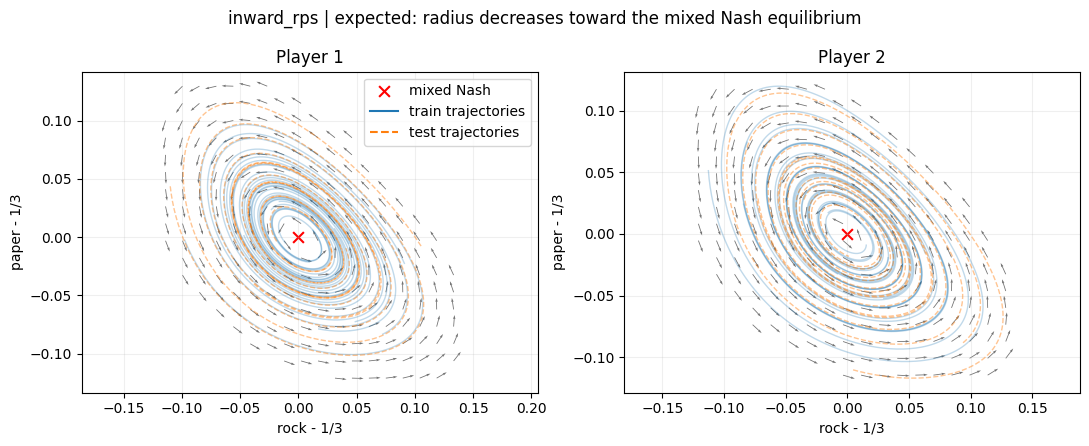

In [4]:
def binned_vector_field(raw, player="p1", bins=18, min_count=3):
    sl = slice(0, 2) if player == "p1" else slice(2, 4)
    dt = float(metadata.get("dt", 1.0))

    x = raw[:, :-1, sl].reshape(-1, 2)
    v = ((raw[:, 1:, sl] - raw[:, :-1, sl]) / dt).reshape(-1, 2)

    x_edges = np.linspace(x[:, 0].min(), x[:, 0].max(), bins + 1)
    y_edges = np.linspace(x[:, 1].min(), x[:, 1].max(), bins + 1)

    centers, vectors = [], []

    for i in range(bins):
        for j in range(bins):
            mask = (
                (x[:, 0] >= x_edges[i]) & (x[:, 0] < x_edges[i + 1]) &
                (x[:, 1] >= y_edges[j]) & (x[:, 1] < y_edges[j + 1])
            )

            if mask.sum() >= min_count:
                centers.append([
                    (x_edges[i] + x_edges[i + 1]) / 2,
                    (y_edges[j] + y_edges[j + 1]) / 2,
                ])
                vectors.append(v[mask].mean(axis=0))

    return np.array(centers), np.array(vectors)


def plot_rps_projection_with_vector_field(train_raw, test_raw=None, n_train=8, n_test=4, bins=18):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    specs = [("p1", slice(0, 2), "Player 1"), ("p2", slice(2, 4), "Player 2")]

    for ax, (player, sl, title) in zip(axes, specs):
        for traj in train_raw[:n_train]:
            ax.plot(traj[:, sl.start], traj[:, sl.stop - 1],
                    color="C0", alpha=0.28, linewidth=1)

        if test_raw is not None:
            for traj in test_raw[:n_test]:
                ax.plot(traj[:, sl.start], traj[:, sl.stop - 1],
                        color="C1", alpha=0.45, linestyle="--", linewidth=1)

        centers, vectors = binned_vector_field(train_raw, player=player, bins=bins)

        if len(centers):
            norms = np.linalg.norm(vectors, axis=1, keepdims=True)
            unit_vectors = vectors / np.maximum(norms, 1e-12)

            ax.quiver(
                centers[:, 0], centers[:, 1],
                unit_vectors[:, 0], unit_vectors[:, 1],
                angles="xy",
                scale_units="xy",
                scale=100,
                width=0.0018,
                color="black",
                alpha=0.55,
            )

        ax.scatter(0, 0, color="red", marker="x", s=60, label="mixed Nash")
        ax.set_title(title)
        ax.set_xlabel("rock - 1/3")
        ax.set_ylabel("paper - 1/3")
        ax.axis("equal")
        ax.grid(alpha=0.2)

    axes[0].plot([], [], color="C0", label="train trajectories")
    axes[0].plot([], [], color="C1", linestyle="--", label="test trajectories")
    axes[0].legend()

    fig.suptitle(f"{metadata.get('regime')} | expected: {metadata.get('expected_radial_behavior')}")
    fig.tight_layout()
    plt.show()

        
plot_rps_projection_with_vector_field(train_raw, test_raw)

In [5]:
TRAIN_CONFIG = {
    "M": 24,
    "P": 2,
    "num_epochs": 300,
    "batches_per_epoch": 30,
    "sequence_length": 200,
    "batch_size": 16,
    "alpha": 0.5,
    "n_interleave": 5,
    "start_learning_rate": 1e-3,
    "end_learning_rate": 1e-5,
    "seed": 11,
}

In [ ]:
#rps_model, rps_train_metrics = train_current_model(train_norm, model_path=RPS_MODEL_PATH, config=TRAIN_CONFIG,)

Training Progress: 100%|██████████| 500/500 [10:26<00:00,  1.25s/it, loss=0.000301]


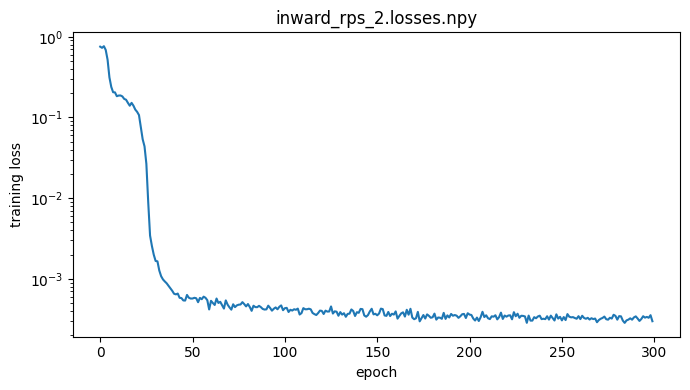

In [6]:
loss_path = RPS_MODEL_PATH.with_suffix(".losses.npy")

if loss_path.exists():
    losses = np.load(loss_path)
    plt.figure(figsize=(7, 4))
    plt.plot(losses)
    plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel("training loss")
    plt.title(loss_path.name)
    plt.tight_layout()
    plt.show()

In [8]:
ctx = load_eval_context(DATA_DIR, RPS_MODEL_PATH, M=TRAIN_CONFIG["M"], P=TRAIN_CONFIG["P"])

trajectory = trajectory_reconstruction_analysis(
    ctx,
    n_rollout=40,
    steps=1200,
    prediction_horizon=10,
    n_bins=6,
    smoothing=20,
    plot=True,
)
print("RPS one-step mse:", trajectory["one_step_mse"])
print("RPS n-step mse:", trajectory["n_step_mse"])
print("RPS rollout mse:", trajectory["rollout_mse"])
print("RPS attractor metrics:", trajectory["attractor_metrics"])


RPS one-step mse: 0.000233
RPS n-step mse: 0.000419
RPS rollout mse: 0.018386
RPS attractor metrics: {'state_space_divergence': 0.153559, 'power_spectrum_error_mean': 0.00226, 'power_spectrum_error_std': 0.000944}


In [9]:
print("one-step mse:", trajectory["one_step_mse"])
print("one-step per-dim mse:", trajectory["one_step_per_dim_mse"])
print("n-step horizon:", trajectory["prediction_horizon"])
print("n-step mse:", trajectory["n_step_mse"])
print("rollout mse:", trajectory["rollout_mse"])
print("attractor metrics:", trajectory["attractor_metrics"])

one-step mse: 0.000233
one-step per-dim mse: [9.4e-05, 6.4e-05, 0.000429, 0.000346]
n-step horizon: 10
n-step mse: 0.000419
rollout mse: 0.018386
attractor metrics: {'state_space_divergence': 0.153559, 'power_spectrum_error_mean': 0.00226, 'power_spectrum_error_std': 0.000944}


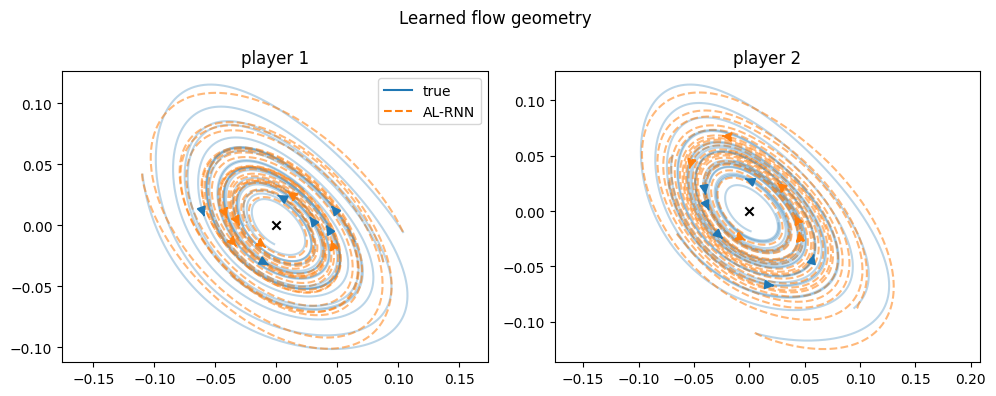

In [10]:
rollout = trajectory["rollout"]
flow = flow_geometry_analysis(ctx, rollout, plot=True)

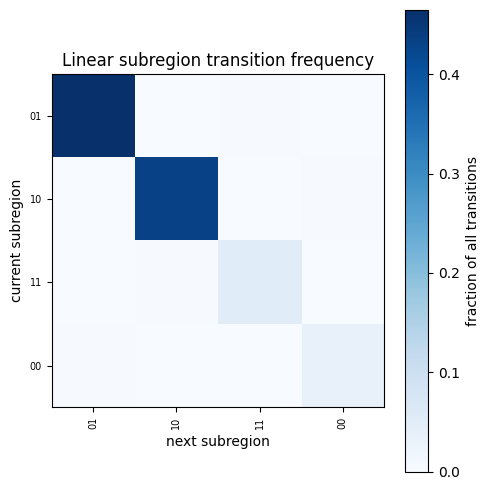

used subregions: 4 / 4
transition connectome shape: (4, 4)
transition connectome finite: True
transition connectome sum: 1.0
transition connectome:
 [[4.64670284e-01 0.00000000e+00 3.04674457e-03 6.26043406e-05]
 [0.00000000e+00 4.33242905e-01 8.34724541e-05 2.87979967e-03]
 [2.08681135e-05 3.06761269e-03 5.36936561e-02 0.00000000e+00]
 [2.90066778e-03 6.26043406e-05 0.00000000e+00 3.62687813e-02]]


In [11]:
used = used_subregion_analysis(rollout["latent"], P=TRAIN_CONFIG["P"])
transition = transition_probability_analysis(rollout["latent"], P=TRAIN_CONFIG["P"], plot=True)

print("used subregions:", used["num_used_subregions"], "/", used["total_possible_subregions"])
print("transition connectome shape:", transition["connectome"].shape)
print("transition connectome finite:", bool(np.isfinite(transition["connectome"]).all()))
print("transition connectome sum:", float(np.nansum(transition["connectome"])))
print("transition connectome:\n", transition["connectome"])

### Newly added:

### Validation of policy:

We first perform a validity check on the long rollout trajectories of the model. To be considered valid, the policy probabilities must satisfy $0 < P < 1$ (strictly greater than 0 and less than 1) for all components, and the sum of the probabilities across all dimensions must equal $1$.

In [13]:
RPS_policy_validity = policy_validity_analysis(
    ctx,
    tol=1e-6,
)

RPS_policy_validity_table = pd.DataFrame(
    [
        {
            "n_test_rollouts": RPS_policy_validity["n_test_rollouts"],
            "steps": RPS_policy_validity["steps"],
            "n_invalid_pred_rollouts": RPS_policy_validity["n_invalid_pred_rollouts"],
            "invalid_pred_rollout_fraction": RPS_policy_validity["invalid_pred_rollout_fraction"],
            "min_pred_probability": RPS_policy_validity["min_pred_probability"],
            "max_pred_probability": RPS_policy_validity["max_pred_probability"],
        }
    ]
)

display(
    RPS_policy_validity_table.style.format(
        {
            "invalid_pred_rollout_fraction": "{:.6g}",
            "min_pred_probability": "{:.6g}",
            "max_pred_probability": "{:.6g}",
            "max_pred_sum_error": "{:.6g}",
        }
    )
)

,n_test_rollouts,steps,n_invalid_pred_rollouts,invalid_pred_rollout_fraction,min_pred_probability,max_pred_probability
0,40,1199,0,0,0.206635,0.465454


For the inward_rps model with $P=2$, all generated trajectories are strictly valid.

### Error analysis over all test dataset

We introduced a new function to analyze long rollout trajectories, which are freely generated from initial points using all test trajectories as ground-truth data. Specifically, we evaluate the average long rollout MSE (averaged across all long rollout trajectories, as well as over all time steps and state dimensions for each individual trajectory). Furthermore, we identify the median and worst case error scenarios among all trajectories."

In [14]:
RPS_all_test_rollout = test_long_rollout_analysis(
    ctx,
    n_bins=6,
    smoothing=20,
)

RPS_all_test_rollout_table = pd.DataFrame(
    [
        {
            "n_test_rollouts": RPS_all_test_rollout["n_test_rollouts"],
            "steps": RPS_all_test_rollout["steps"],
            "mean_rollout_mse": RPS_all_test_rollout["mean_rollout_mse"],
            "median_rollout_mse": RPS_all_test_rollout["median_rollout_mse"],
            "worst_rollout_mse": RPS_all_test_rollout["worst_rollout_mse"],
            "state_space_divergence": RPS_all_test_rollout["state_space_divergence"],
            "power_spectrum_error_mean": RPS_all_test_rollout["power_spectrum_error_mean"],
            "power_spectrum_error_std": RPS_all_test_rollout["power_spectrum_error_std"],
        }
    ]
)

display(
    RPS_all_test_rollout_table.style.format(
        {
            "mean_rollout_mse": "{:.6g}",
            "median_rollout_mse": "{:.6g}",
            "worst_rollout_mse": "{:.6g}",
            "state_space_divergence": "{:.6g}",
            "power_spectrum_error_mean": "{:.6g}",
            "power_spectrum_error_std": "{:.6g}",
        }
    )
)

,n_test_rollouts,steps,mean_rollout_mse,median_rollout_mse,worst_rollout_mse,state_space_divergence,power_spectrum_error_mean,power_spectrum_error_std
0,40,1199,0.0183861,0.0140501,0.0458776,0.153559,0.00225973,0.000943972


In our exemplar model, the `mean_rollout_mse` is approximately $0.018$, with a `median_rollout_mse` of $0.014$ across all long-rollout trajectories, and a `worst_rollout_mse` of about $0.046$. Furthermore, utilizing all ground truth and long rollout trajectories, the computed `state_space_divergence` is around $0.15$, and the `power_spectrum_error_mean` is approximately $0.002$. Overall, these results are highly promising: the MSE remains notably small even in the worst-case scenario, and the error in the state-space distribution is consistently low, demonstrating the robust reconstruction capability of our model.

### Radius and Rotation analysis

Radius: For the calculation of the radius, we compute the distance from the predicted trajectory at each time step to the Nash equilibrium and denote it as $r$, defined as 

$$ r = ||q_t - q^*||$$

A decreasing $r$ over time indicates that the trajectory is gradually approaching the Nash equilibrium. If $r$ remains largely unchanged, it suggests that the trajectory may exhibit periodic motion around the Nash equilibrium. Conversely, an increasing $r$ implies that the trajectory is moving away from the Nash equilibrium, corresponding to an outward shaped trajectory.

Near the Nash equilibrium, via local linearization, we have $r_{t+1} \approx J r_t$ and $r_{t+1} \approx J^t r_0$, which can be further expressed using eigenvalues, where the spectral radius (the maximum eigenvalue) dominates the direction. Furthermore, through polar coordinate transformation, the radius under the dominant mode can be approximated as $r_t \approx r_0 \rho^t$, where $r_0$ is a constant. 

To better quantify this trend, in practice, we take the logarithm of the radius and fit the following linear relationship: $\log r_t \approx \beta t + c$. Here, $\beta$ represents the rate of change of the radius: $\beta < 0$ indicates that the radius contracts toward the Nash equilibrium, $\beta \approx 0$ means the radius remains approximately constant, and $\beta > 0$ indicates outward expansion or divergence. 

In addition, the code reports the mean initial radius, mean final radius, and the minimum and maximum radii of the generated trajectories, which helps us understand both the global progression and the final state of the long rollout trajectories.

Rotation: Regarding the evaluation of rotation, we leverage the 2D cross product(Cormen - 2009 - Introduction to algorithms). For any given player, we consider the 2D coordinates of the policy probability, denoted as $v_t = (x_t, y_t)$. We compute the angular velocity via a polar coordinate transformation as 
$$\omega = (\theta_T - \theta_0) / T$$

where $\theta_t = \text{atan2}(y_t, x_t)$. 

By calculating and comparing the average angular velocities of Player 1 and Player 2 across both the predicted and ground-truth trajectories, we can evaluate whether the model successfully replicates the rotational speed and direction of the ground truth.

In addition to the average angular velocity, we perform a step-by-step comparison of the rotational directions between the predicted and ground truth trajectories. The displacement between consecutive time steps is defined as 
$$\Delta v_t = v_{t+1} - v_t = (\Delta x_t, \Delta y_t)$$

We then utilize the 2D cross product to determine the local rotation direction, given by $z_t = x_t \Delta y_t - y_t \Delta x_t$. A value of $z_t > 0$ indicates counter-clockwise (CCW) rotation, while $z_t < 0$ denotes clockwise (CW) rotation. For each player, we quantify the rotation direction accuracy by comparing the ground-truth data against the long-rollout trajectories, and further report the joint rotation accuracy.

In [15]:
rps_polar_geometry = polar_geometry_analysis(
    ctx,
    radius_eps=1e-8,
    include_rotation=False,
)

radius_columns = [
    "regime",
    "P",
    #"model_path",
    "n_test_rollouts",
    "steps",
    "initial_radius_mean",
    "final_radius_mean",
    "generated_radius_min",
    "generated_radius_max",
    "pred_log_radius_slope_mean",
    "pred_log_radius_slope_std",
]

rps_radius_geometry_row = {
    "regime": REGIME,
    "P": TRAIN_CONFIG["P"],
    #"model_path": str(RPS_MODEL_PATH),
}
rps_radius_geometry_row.update(
    {key: rps_polar_geometry[key] for key in radius_columns if key in rps_polar_geometry}
)

rps_radius_geometry_table = pd.DataFrame([rps_radius_geometry_row], columns=radius_columns)

display(
    rps_radius_geometry_table.style.format(
        {
            "initial_radius_mean": "{:.6g}",
            "final_radius_mean": "{:.6g}",
            "generated_radius_min": "{:.6g}",
            "generated_radius_max": "{:.6g}",
            "pred_log_radius_slope_mean": "{:.6g}",
            "pred_log_radius_slope_std": "{:.6g}",
        }
    )
)


,regime,P,n_test_rollouts,steps,initial_radius_mean,final_radius_mean,generated_radius_min,generated_radius_max,pred_log_radius_slope_mean,pred_log_radius_slope_std
0,inward_rps,2,40,1199,0.118593,0.048879,0.0218177,0.176313,-0.000760029,5.72886e-05


In our exemplar model, `inward_rps` with $P=2$, the initial_radius_mean of the long rollouts is approximately 0.1186, while the `final_radius_mean` is around $0.0489$. This demonstrates a clear reduction in the radius over time. Furthermore, the `pred_log_radius_slope_mean` is approximately $-0.00076 < 0$, which confirms that the radius contracts toward the Nash equilibrium.

In [25]:
rps_rotation_geometry = polar_geometry_analysis(
    ctx,
    radius_eps=1e-8,
    include_rotation=True,
)

rotation_columns = [
    "regime",
    "P",
    #"model_path",
    "n_test_rollouts",
    "steps",
    "pred_angular_velocity_p1_mean",
    "true_angular_velocity_p1_mean",
    "pred_rotation_sign_sum_p1",
    "true_rotation_sign_sum_p1",
    "pred_angular_velocity_p2_mean",
    "true_angular_velocity_p2_mean",
    "pred_rotation_sign_sum_p2",
    "true_rotation_sign_sum_p2",
    "step_rotation_accuracy_joint",
]

rps_rotation_geometry_row = {
    "regime": REGIME,
    "P": TRAIN_CONFIG["P"],
    #"model_path": str(RPS_MODEL_PATH),
}
rps_rotation_geometry_row.update(
    {key: rps_rotation_geometry[key] for key in rotation_columns if key in rps_rotation_geometry}
)

rps_rotation_geometry_table = pd.DataFrame([rps_rotation_geometry_row], columns=rotation_columns)

display(
    rps_rotation_geometry_table.style.format(
        {
            "pred_angular_velocity_p1_mean": "{:.6g}",
            "true_angular_velocity_p1_mean": "{:.6g}",
            "pred_rotation_sign_sum_p1": "{:.0f}",
            "true_rotation_sign_sum_p1": "{:.0f}",
            "pred_angular_velocity_p2_mean": "{:.6g}",
            "true_angular_velocity_p2_mean": "{:.6g}",
            "pred_rotation_sign_sum_p2": "{:.0f}",
            "true_rotation_sign_sum_p2": "{:.0f}",
            "step_rotation_accuracy_joint": "{:.6g}",
        }
    )
)


,regime,P,n_test_rollouts,steps,pred_angular_velocity_p1_mean,true_angular_velocity_p1_mean,pred_rotation_sign_sum_p1,true_rotation_sign_sum_p1,pred_angular_velocity_p2_mean,true_angular_velocity_p2_mean,pred_rotation_sign_sum_p2,true_rotation_sign_sum_p2,step_rotation_accuracy_joint
0,inward_rps,2,40,1199,0.0184707,0.0186426,47958,47960,0.0185655,0.0185742,47948,47960,0.999854


As can be observed, the predicted and ground truth trajectories exhibit highly similar rotational angular velocities, both rotating in a counter-clockwise direction. Although a tiny fraction of time steps show inconsistent rotational signs during the step-by-step evaluation, this indicates that the model has almost perfectly replicated the local rotational direction. A minimal perturbation could easily flip the sign of $\operatorname{sign}(z_t)$, thereby inducing slight discrepancies in the local rotational signs.

## Summary of reconstruction results from the separate RPS model at different P values

In [26]:
RPS_SWEEP_MODEL_DIR = Path("models/rps_seperate_model")
RPS_SWEEP_DATA_ROOT = Path("datasets/RPS_data")
RPS_SWEEP_REGIMES = ["center_rps", "inward_rps", "outward_rps"]
RPS_SWEEP_PS = [1, 2, 4, 8]
RPS_SWEEP_M = 24

rps_validity_rows = []

for regime in RPS_SWEEP_REGIMES:
    data_dir = RPS_SWEEP_DATA_ROOT / regime
    for P in RPS_SWEEP_PS:
        model_path = RPS_SWEEP_MODEL_DIR / f"{regime}_{P}.pt"
        ctx_p = load_eval_context(data_dir, model_path, M=RPS_SWEEP_M, P=P)
        validity_p = policy_validity_analysis(ctx_p, tol=1e-6)

        rps_validity_rows.append(
            {
                "regime": regime,
                "P": P,
                "n_test_rollouts": validity_p["n_test_rollouts"],
                "steps": validity_p["steps"],
                "n_invalid_pred_rollouts": validity_p["n_invalid_pred_rollouts"],
                "invalid_pred_rollout_fraction": validity_p["invalid_pred_rollout_fraction"],
                "min_pred_probability": validity_p["min_pred_probability"],
                "max_pred_probability": validity_p["max_pred_probability"],
            }
        )

rps_validity_summary = pd.DataFrame(rps_validity_rows).sort_values(["regime", "P"]).reset_index(drop=True)

display(
    rps_validity_summary.style.format(
        {
            "invalid_pred_rollout_fraction": "{:.6g}",
            "min_pred_probability": "{:.6g}",
            "max_pred_probability": "{:.6g}",
            "max_pred_sum_error": "{:.6g}",
        }
    )
)


,regime,P,n_test_rollouts,steps,n_invalid_pred_rollouts,invalid_pred_rollout_fraction,min_pred_probability,max_pred_probability
0,center_rps,1,40,1199,24,0.6,-0.309585,0.97117
1,center_rps,2,40,1199,0,0,0.157741,0.512741
2,center_rps,4,40,1199,0,0,0.199409,0.480624
3,center_rps,8,40,1199,0,0,0.194109,0.487396
4,inward_rps,1,40,1199,0,0,0.208232,0.45733
5,inward_rps,2,40,1199,0,0,0.206635,0.465454
6,inward_rps,4,40,1199,0,0,0.207593,0.462825
7,inward_rps,8,40,1199,0,0,0.206671,0.464622
8,outward_rps,1,40,1199,0,0,0.147394,0.515241
9,outward_rps,2,40,1199,0,0,0.0611072,0.608785


We conducted validity checks across all models and observed that the trajectories generated by the vast majority of the models are valid. The only major exception is the `center_rps` model with $P=1$, where a large portion of the trajectories violated the constraints. Additionally, the `outward_rps` model also generated some trajectories that exceeded the boundaries when $P=4$ and $P=8$.

In [27]:
RPS_SWEEP_MODEL_DIR = Path("models/rps_seperate_model")
RPS_SWEEP_DATA_ROOT = Path("datasets/RPS_data")
RPS_SWEEP_REGIMES = ["center_rps", "inward_rps", "outward_rps"]
RPS_SWEEP_PS = [1, 2, 4, 8]
RPS_SWEEP_M = 24
RPS_SWEEP_N_BINS = 6
RPS_SWEEP_SMOOTHING = 20

rps_summary_rows = []

for regime in RPS_SWEEP_REGIMES:
    data_dir = RPS_SWEEP_DATA_ROOT / regime
    for P in RPS_SWEEP_PS:
        model_path = RPS_SWEEP_MODEL_DIR / f"{regime}_{P}.pt"
        ctx_p = load_eval_context(data_dir, model_path, M=RPS_SWEEP_M, P=P)
        rollout_p = test_long_rollout_analysis(
            ctx_p,
            n_bins=RPS_SWEEP_N_BINS,
            smoothing=RPS_SWEEP_SMOOTHING,
        )

        rps_summary_rows.append(
            {
                "regime": regime,
                "P": P,
                "n_test_rollouts": rollout_p["n_test_rollouts"],
                "steps": rollout_p["steps"],
                "mean_rollout_mse": rollout_p["mean_rollout_mse"],
                "median_rollout_mse": rollout_p["median_rollout_mse"],
                "worst_rollout_mse": rollout_p["worst_rollout_mse"],
                "state_space_divergence": rollout_p["state_space_divergence"],
                "power_spectrum_error_mean": rollout_p["power_spectrum_error_mean"],
                "power_spectrum_error_std": rollout_p["power_spectrum_error_std"],
            }
        )

rps_p_summary = pd.DataFrame(rps_summary_rows).sort_values(["regime", "P"]).reset_index(drop=True)

display(
    rps_p_summary.style.format(
        {
            "mean_rollout_mse": "{:.6g}",
            "median_rollout_mse": "{:.6g}",
            "worst_rollout_mse": "{:.6g}",
            "state_space_divergence": "{:.6g}",
            "power_spectrum_error_mean": "{:.6g}",
            "power_spectrum_error_std": "{:.6g}",
        }
    )
)


,regime,P,n_test_rollouts,steps,mean_rollout_mse,median_rollout_mse,worst_rollout_mse,state_space_divergence,power_spectrum_error_mean,power_spectrum_error_std
0,center_rps,1,40,1199,2.45908,2.45615,6.14796,1.88621,0.0156169,0.00515094
1,center_rps,2,40,1199,0.0762027,0.0680605,0.25291,0.578978,0.00521299,0.00158363
2,center_rps,4,40,1199,0.0336675,0.0265554,0.0943657,0.683662,0.00413652,0.00160004
3,center_rps,8,40,1199,0.0490139,0.0458328,0.13545,0.79132,0.00419797,0.00172251
4,inward_rps,1,40,1199,0.0289709,0.0226376,0.0896483,0.183086,0.00251102,0.00126111
5,inward_rps,2,40,1199,0.0183861,0.0140501,0.0458776,0.153559,0.00225973,0.000943972
6,inward_rps,4,40,1199,0.0225669,0.0195443,0.0584974,0.155132,0.00259038,0.00119752
7,inward_rps,8,40,1199,0.0284511,0.0282203,0.105955,0.131446,0.00289057,0.00121156
8,outward_rps,1,40,1199,0.551506,0.438844,1.68105,4.65957,0.0144212,0.00763299
9,outward_rps,2,40,1199,0.318602,0.274657,0.825363,1.31168,0.0108586,0.00363161


We conducted an error analysis across all developed models. When the generated trajectories are entirely valid, the overall errors of the models remain consistently low. Among them, only the outward_rps model exhibits a relatively higher error. This discrepancy likely stems from the fact that outward trajectories gradually deviate from the Nash equilibrium, which potentially amplifies the errors over time. Based on the performance metrics, the best performing configurations selected from the table are the `center_rps` model with $P=4$, the `inward_rps` model with $P=2$, and the `outward_rps` model with $P=2$.

Next, we will proceed with an analysis of the radius and rotation direction for the long rollout trajectories of these three selected models.

### Raduis and Rotation Analysis of `certer_rps` with $P=4$, `inward_rps` with $P=2$ and `outward_rps` with $P=2$

In [28]:
RPS_POLAR_MODEL_DIR = Path("models/rps_seperate_model")
RPS_POLAR_DATA_ROOT = Path("datasets/RPS_data")
RPS_POLAR_M = 24
RPS_POLAR_EXPERIMENTS = [
    ("center_rps", 4),
    ("inward_rps", 2),
    ("outward_rps", 2),
]

rps_radius_rows = []

for regime, P in RPS_POLAR_EXPERIMENTS:
    data_dir = RPS_POLAR_DATA_ROOT / regime
    model_path = RPS_POLAR_MODEL_DIR / f"{regime}_{P}.pt"
    ctx_p = load_eval_context(data_dir, model_path, M=RPS_POLAR_M, P=P)
    geometry_p = polar_geometry_analysis(ctx_p, radius_eps=1e-8, include_rotation=False)

    rps_radius_rows.append(
        {
            "regime": regime,
            "P": P,
            #"model_path": str(model_path),
            "n_test_rollouts": geometry_p["n_test_rollouts"],
            "steps": geometry_p["steps"],
            "initial_radius_mean": geometry_p["initial_radius_mean"],
            "final_radius_mean": geometry_p["final_radius_mean"],
            "generated_radius_min": geometry_p["generated_radius_min"],
            "generated_radius_max": geometry_p["generated_radius_max"],
            "pred_log_radius_slope_mean": geometry_p["pred_log_radius_slope_mean"],
            "pred_log_radius_slope_std": geometry_p["pred_log_radius_slope_std"],
        }
    )

rps_radius_table = pd.DataFrame(rps_radius_rows)

display(
    rps_radius_table.style.format(
        {
            "initial_radius_mean": "{:.6g}",
            "final_radius_mean": "{:.6g}",
            "generated_radius_min": "{:.6g}",
            "generated_radius_max": "{:.6g}",
            "pred_log_radius_slope_mean": "{:.6g}",
            "pred_log_radius_slope_std": "{:.6g}",
        }
    )
)


,regime,P,n_test_rollouts,steps,initial_radius_mean,final_radius_mean,generated_radius_min,generated_radius_max,pred_log_radius_slope_mean,pred_log_radius_slope_std
0,center_rps,4,40,1199,0.118593,0.12424,0.0503862,0.215407,-6.72334e-06,6.4813e-05
1,inward_rps,2,40,1199,0.118593,0.048879,0.0218177,0.176313,-0.000760029,5.72886e-05
2,outward_rps,2,40,1199,0.118593,0.246274,0.0618605,0.395574,0.0005671,0.00012208


We conducted a radius analysis on the three selected models. For the `center_rps` model, the final mean radius of the generated trajectories is approximately $0.1242$, which is remarkably close to the initial state of $0.1186$. The mean slope of the logarithmic radius is $-6.72334 \times 10^{-6}$, which is virtually zero. This indicates that under the center regime, the trajectories generated by the model exhibit no prominent tendency toward inward contraction or outward divergence; instead, they roughly maintain a similar radius around the Nash equilibrium. Although the final radius is slightly higher than the initial radius, the magnitude of $\beta$ is extremely small, with a standard deviation of $6.4813 \times 10^{-5}$.

For `inward_rps`, the final mean radius decreases to $0.0489$, which is noticeably smaller than the initial radius, and the `pred_log_radius_slope_mean` is approximately $-0.00076$, presenting a significantly negative value. This confirms that the generated trajectories continuously contract toward the Nash equilibrium during the rollout process. Conversely, for `outward_rps`, the final mean radius increases to $0.2463$, which is substantially larger than the initial radius. The `pred_log_radius_slope_mean` is around $0.0005671$, a positive value that demonstrates a stable radial expansion trend in the generated rollout trajectories.

In [30]:
RPS_POLAR_MODEL_DIR = Path("models/rps_seperate_model")
RPS_POLAR_DATA_ROOT = Path("datasets/RPS_data")
RPS_POLAR_M = 24
RPS_POLAR_EXPERIMENTS = [
    ("center_rps", 4),
    ("inward_rps", 2),
    ("outward_rps", 2),
]

rps_rotation_rows = []

for regime, P in RPS_POLAR_EXPERIMENTS:
    data_dir = RPS_POLAR_DATA_ROOT / regime
    model_path = RPS_POLAR_MODEL_DIR / f"{regime}_{P}.pt"
    ctx_p = load_eval_context(data_dir, model_path, M=RPS_POLAR_M, P=P)
    geometry_p = polar_geometry_analysis(ctx_p, radius_eps=1e-8, include_rotation=True)

    rps_rotation_rows.append(
        {
            "regime": regime,
            "P": P,
            #"model_path": str(model_path),
            #"n_test_rollouts": geometry_p["n_test_rollouts"],
            #"steps": geometry_p["steps"],
            "pred_angular_velocity_p1_mean": geometry_p["pred_angular_velocity_p1_mean"],
            "true_angular_velocity_p1_mean": geometry_p["true_angular_velocity_p1_mean"],
            "pred_rotation_sign_sum_p1": geometry_p["pred_rotation_sign_sum_p1"],
            "true_rotation_sign_sum_p1": geometry_p["true_rotation_sign_sum_p1"],
            "pred_angular_velocity_p2_mean": geometry_p["pred_angular_velocity_p2_mean"],
            "true_angular_velocity_p2_mean": geometry_p["true_angular_velocity_p2_mean"],
            "pred_rotation_sign_sum_p2": geometry_p["pred_rotation_sign_sum_p2"],
            "true_rotation_sign_sum_p2": geometry_p["true_rotation_sign_sum_p2"],
        }
    )

rps_rotation_table = pd.DataFrame(rps_rotation_rows)

display(
    rps_rotation_table.style.format(
        {
            "pred_angular_velocity_p1_mean": "{:.6g}",
            "true_angular_velocity_p1_mean": "{:.6g}",
            "pred_rotation_sign_sum_p1": "{:.0f}",
            "true_rotation_sign_sum_p1": "{:.0f}",
            "pred_angular_velocity_p2_mean": "{:.6g}",
            "true_angular_velocity_p2_mean": "{:.6g}",
            "pred_rotation_sign_sum_p2": "{:.0f}",
            "true_rotation_sign_sum_p2": "{:.0f}",
        }
    )
)


,regime,P,pred_angular_velocity_p1_mean,true_angular_velocity_p1_mean,pred_rotation_sign_sum_p1,true_rotation_sign_sum_p1,pred_angular_velocity_p2_mean,true_angular_velocity_p2_mean,pred_rotation_sign_sum_p2,true_rotation_sign_sum_p2
0,center_rps,4,0.0198882,0.0200193,47954,47960,0.0198223,0.019952,47960,47960
1,inward_rps,2,0.0184707,0.0186426,47958,47960,0.0185655,0.0185742,47948,47960
2,outward_rps,2,0.0202404,0.0210682,47938,47960,0.0206723,0.0208473,47954,47960


The evaluation of rotation angles yields results consistent with the exemplar model: the generated and ground truth trajectories exhibit highly similar rotational angular velocities, both rotating in a counter-clockwise direction. The generated values align very closely with the ground truth, demonstrating that the ALRNN successfully captures the cyclical velocity inherent in the RPS dynamics. Although there are localized discrepancies in the composite rotational signs, these errors do not imply an inverted rotation direction. Instead, they are likely caused by a near-zero rotation at certain time steps along the trajectory. Since such instances account for only a small fraction, the overall rotational direction remains highly stable.

---------
Previous Analysis:

Explanation: Here, `n_rollout` represents the number of trajectories selected from the test dataset.

The tabular results indicate that ALRNN is generally effective at reconstructing separate RPS dynamics, though its performance depends significantly on the dynamical regime and $P$.

For RPS games with "center" trajectories, the model's reconstruction capability improves markedly as $P$ increases from 1 to 4: the one-step MSE drops from 0.01 to 0.000133, the free- rolloutu trajectory rollout_MSE falls from 1.59 to 0.0219, and the state-space divergence decreases from 10.31 to 0.37. This suggests that higher piecewise-linear capacity better captures the geometric structure of neutral cyclic orbits. However, performance degrades slightly at $P=8$ compared to $P=4$, implying that an excessively high number of partitions does not necessarily yield more stable long-term rollouts.

Dataset from RPS games with "inward" trajectories proved the most stable to reconstruct; one-step MSE values ​​remained low across all $P$ settings, and rollout MSE stayed within the 0.013–0.04 range. Specifically, $P=2$ yielded the lowest rollout MSE, while $P=4$ achieved the lowest state-space divergence, indicating that convergent dynamics are relatively easier for AL-RNN to learn.

In contrast, reconstructing data from "outward" RPS trajectories proved the most challenging. Although one-step MSE values ​​were low at $P=2$ and $P=8$, both rollout MSE and state-space divergence were significantly higher than those observed for "inward" or "center" trajectories—with particularly poor long-term reconstruction at $P=4$. This demonstrates that while ALRNN can learn the local one-step dynamics of separate RPS systems, long-term autonomous reconstruction is prone to error accumulation in "outward" dynamics, where trajectories diverge from the Nash equilibrium and errors amplify over time.

Overall, these results suggest that ALRNN outstands at local prediction and the reconstruction of inward or center trajectories, while performing less effectively on "outward" trajectories。 However, its long-term autonomous reconstruction is more sensitive to the choice of $P$ and to the stability properties of the underlying dynamics, with divergent outward dynamics showing the greatest difficulty.

## Modifications made from June 29, 2026, to July 2, 2026:

- First, I conducted invalidity checks and MSE calculations for the generated long rollouts across all previously completed RPS separate experiments ($P = 1, 2, 4, 8$). These statistical results have replaced the content of the previous version. It can be observed that for `center_rps` at $P = 1$, most rollout trajectories turned out to be invalid (Explanation: here, a trajectory is defined as invalid if it violates the constraints at even a single time step). When $P$ is too small, the model partitions too few linear subregions to fully characterize the non-linear structure of the true system. However, as $P$ increases, there are enough piecewise linear (PWL) regions to capture the true dynamics, making all long rollout trajectories valid. That being said, different results emerged in the `outward_rps` experiments.

- In the `outward_rps` experiments, all long rollout trajectories were valid when $P = 2$. However, when $P = 4 ,8$, the long rollout running performance on the test dataset deteriorated, and invalid trajectories appeared. This might be because a $P$ value that is too large cuts the non-linear structure too finely, making the transitions between linear subregions highly complex. As a result, instead of learning a clean and stable dynamical structure, the model might be learning a lot of redundant local regions.

- I further experimented with training the model using more epochs. I discovered that as the number of epochs increased, the exact same issue occurred as with the WoLF model. When the training epochs for the RPS separate model were increased to $1000$, the ALRNN long rollout trajectories began to drift, and the long-term dynamical structure learned by the model could not remain stable. Therefore, I still chose to keep the training epochs at a relatively low level.

-----
previous result
## 4.Cross-prediction test on Rock-Paper-Scissors separate datasets

Next, we consider conducting cross-prediction experiments using the separate RPS models, with the goal of evaluating whether the models exhibit good generalization ability. 

We select the best-performing models from the separate experiments as the test models: `center_rps_4` with $P=4$, `inward_rps_4` with $P=4$, and `outward_rps_2` with $P=2$. Each model is then used to make predictions on the target test datasets, and we analyze the reconstructed phase portraits together with the corresponding error metrics.

In [45]:
from evaluation.test_long_rollout import test_long_rollout_analysis

RPS_CROSS_DATA_ROOT = Path("datasets/RPS_data")
RPS_CROSS_MODEL_DIR = Path("models/rps_seperate_model")
RPS_CROSS_M = 24
RPS_CROSS_N_BINS = 6
RPS_CROSS_SMOOTHING = 20
RPS_CROSS_STEPS = 1000
RPS_CROSS_PREDICTION_HORIZON = 10

RPS_CROSS_MODELS = {
    "center_rps": {"P": 4, "model_path": RPS_CROSS_MODEL_DIR / "center_rps_4.pt"},
    "inward_rps": {"P": 2, "model_path": RPS_CROSS_MODEL_DIR / "inward_rps_2.pt"},
    "outward_rps": {"P": 2, "model_path": RPS_CROSS_MODEL_DIR / "outward_rps_2.pt"},
}
RPS_CROSS_TARGETS = ["center_rps", "inward_rps", "outward_rps"]


def normalize_with_metadata(x, metadata):
    norm = metadata.get("normalization", {})
    mean = np.asarray(norm.get("mean", np.zeros(x.shape[-1])), dtype=np.float32)
    std = np.asarray(norm.get("std", np.ones(x.shape[-1])), dtype=np.float32)
    return ((x - mean) / std).astype(np.float32)


def make_cross_eval_context(source_regime, target_regime, model_info):
    source_data = load_dataset(RPS_CROSS_DATA_ROOT / source_regime)
    target_data = load_dataset(RPS_CROSS_DATA_ROOT / target_regime)
    source_metadata = source_data["metadata"]

    cross_data = {
        "data_dir": RPS_CROSS_DATA_ROOT / target_regime,
        "metadata": source_metadata,
        "train_norm": normalize_with_metadata(target_data["train_raw"], source_metadata),
        "test_norm": normalize_with_metadata(target_data["test_raw"], source_metadata),
        "train_raw": target_data["train_raw"],
        "test_raw": target_data["test_raw"],
        "target_metadata": target_data["metadata"],
        "source_metadata": source_metadata,
    }

    N = cross_data["test_norm"].shape[-1]
    model = load_model(
        model_info["model_path"],
        M=RPS_CROSS_M,
        P=model_info["P"],
        N=N,
    )

    return {
        "data": cross_data,
        "model": model,
        "model_path": model_info["model_path"],
        "M": RPS_CROSS_M,
        "P": model_info["P"],
        "N": N,
        "device": "cpu",
    }


rps_cross_rows = []
rps_cross_rollouts = {}

for source_regime, model_info in RPS_CROSS_MODELS.items():
    for target_regime in RPS_CROSS_TARGETS:
        ctx_cross = make_cross_eval_context(source_regime, target_regime, model_info)
        rollout_cross = test_long_rollout_analysis(
            ctx_cross,
            n_bins=RPS_CROSS_N_BINS,
            smoothing=RPS_CROSS_SMOOTHING,
        )
        rps_cross_rollouts[(source_regime, target_regime)] = rollout_cross["rollout"]

        rps_cross_rows.append(
            {
                "source_model": source_regime,
                "target_data": target_regime,
                "P": model_info["P"],
                "n_test_rollouts": rollout_cross["n_test_rollouts"],
                "steps": rollout_cross["steps"],
                "mean_rollout_mse": rollout_cross["mean_rollout_mse"],
                "median_rollout_mse": rollout_cross["median_rollout_mse"],
                "worst_rollout_mse": rollout_cross["worst_rollout_mse"],
                "state_space_divergence": rollout_cross["state_space_divergence"],
                "power_spectrum_error_mean": rollout_cross["power_spectrum_error_mean"],
                "power_spectrum_error_std": rollout_cross["power_spectrum_error_std"],
            }
        )

rps_cross_summary = pd.DataFrame(rps_cross_rows).sort_values(["source_model", "target_data"]).reset_index(drop=True)

display(
    rps_cross_summary.style.format(
        {
            "mean_rollout_mse": "{:.6g}",
            "median_rollout_mse": "{:.6g}",
            "worst_rollout_mse": "{:.6g}",
            "state_space_divergence": "{:.6g}",
            "power_spectrum_error_mean": "{:.6g}",
            "power_spectrum_error_std": "{:.6g}",
        }
    )
)


,source_model,target_data,P,n_test_rollouts,steps,mean_rollout_mse,median_rollout_mse,worst_rollout_mse,state_space_divergence,power_spectrum_error_mean,power_spectrum_error_std
0,center_rps,center_rps,4,40,1199,0.0336676,0.0265554,0.0943659,0.683662,0.00413388,0.00159964
1,center_rps,inward_rps,4,40,1199,0.496989,0.416074,1.03381,5.34294,0.0207235,0.00590048
2,center_rps,outward_rps,4,40,1199,1.93159,1.90888,2.63172,4.1207,0.011764,0.00382706
3,inward_rps,center_rps,2,40,1199,1.29218,1.26629,2.36255,1.74621,0.0221043,0.00621459
4,inward_rps,inward_rps,2,40,1199,0.0183861,0.0140501,0.0458776,0.153559,0.0022601,0.000947837
5,inward_rps,outward_rps,2,40,1199,7.83259,7.60974,13.3958,5.55588,0.0215535,0.00597055
6,outward_rps,center_rps,2,40,1199,0.240909,0.245175,0.480555,1.83807,0.011686,0.003302
7,outward_rps,inward_rps,2,40,1199,0.669404,0.652044,1.21895,9.30265,0.0242528,0.00611641
8,outward_rps,outward_rps,2,40,1199,0.318602,0.274658,0.825363,1.31168,0.0108588,0.00363081


The cross-prediction summary above now focuses only on all-test long free-running rollout performance. Each source model is initialized from every test trajectory in the target dataset and then rolled out autonomously. Therefore, the reported `mean_rollout_mse`, `median_rollout_mse`, and `worst_rollout_mse` measure long-horizon reconstruction under accumulated model error rather than teacher-forced local prediction.


Within-regime source-target pairs are expected to perform better because the learned autonomous dynamics match the radial behavior of the target data. Cross-regime pairs are harder: an inward-trained model tends to contract trajectories, an outward-trained model tends to expand them, and a center-trained model tends to preserve cyclic motion. These regime-specific biases can create large free-rollout errors when transferred to a different target dynamics.


The state-space divergence and power-spectrum error complement the MSE values by measuring geometric and temporal-frequency mismatch. Together, these metrics describe whether the cross-predicted autonomous trajectory occupies the correct region of state space and whether its temporal structure resembles the target dynamics.


In [46]:
def assert_cross_rollout_target_alignment(cross_rollouts, trajectory_idx=0, max_steps=1000):
    sources = list(RPS_CROSS_MODELS.keys())
    for target_regime in RPS_CROSS_TARGETS:
        reference = cross_rollouts[(sources[0], target_regime)]["target_raw"][trajectory_idx, :max_steps]
        for source_regime in sources[1:]:
            candidate = cross_rollouts[(source_regime, target_regime)]["target_raw"][trajectory_idx, :max_steps]
            if not np.allclose(reference, candidate, equal_nan=True):
                raise ValueError(f"Target trajectory mismatch for {target_regime} across source models.")
            

def cross_prediction_pair(source_regime, target_regime, mode, trajectory_idx=0, max_steps=1000, n_step=10):
    """
    cross prediction using test dataset from target regime and model from source regime
    """
    if mode == "free_rollout":
        # Free rollout is autonomous after the target trajectory initial condition.
        # target_raw and pred_raw must come from the same source-target rollout object.
        rollout = rps_cross_rollouts[(source_regime, target_regime)]
        true_4d = rollout["target_raw"][trajectory_idx, :max_steps]
        pred_4d = rollout["pred_raw"][trajectory_idx, :max_steps]
        return true_4d, pred_4d

    ctx_cross = make_cross_eval_context(source_regime, target_regime, RPS_CROSS_MODELS[source_regime])

    if mode == "one_step":
        # one-step prediction uses the true trajectory as input for each step, so we can use the target trajectory as the ground truth.
        true_4d = ctx_cross["data"]["test_raw"][trajectory_idx, 1:max_steps]
        current_norm = ctx_cross["data"]["test_norm"][trajectory_idx, :max_steps - 1]
        pred_norm = predict_one_step(ctx_cross["model"], current_norm)
    
    elif mode == "n_step":
        # n-step prediction uses the true trajectory as input for the first step, then rolls out autonomously for n steps.
        true_4d = ctx_cross["data"]["test_raw"][trajectory_idx, n_step:max_steps]
        current_norm = ctx_cross["data"]["test_norm"][trajectory_idx, :max_steps - n_step]
        pred_norm = predict_n_step(ctx_cross["model"], current_norm, n=n_step)
    
    else:
        raise ValueError(f"Unknown prediction mode: {mode}")

    pred_4d = unnormalize(pred_norm, ctx_cross["data"]["metadata"])
    return true_4d, pred_4d

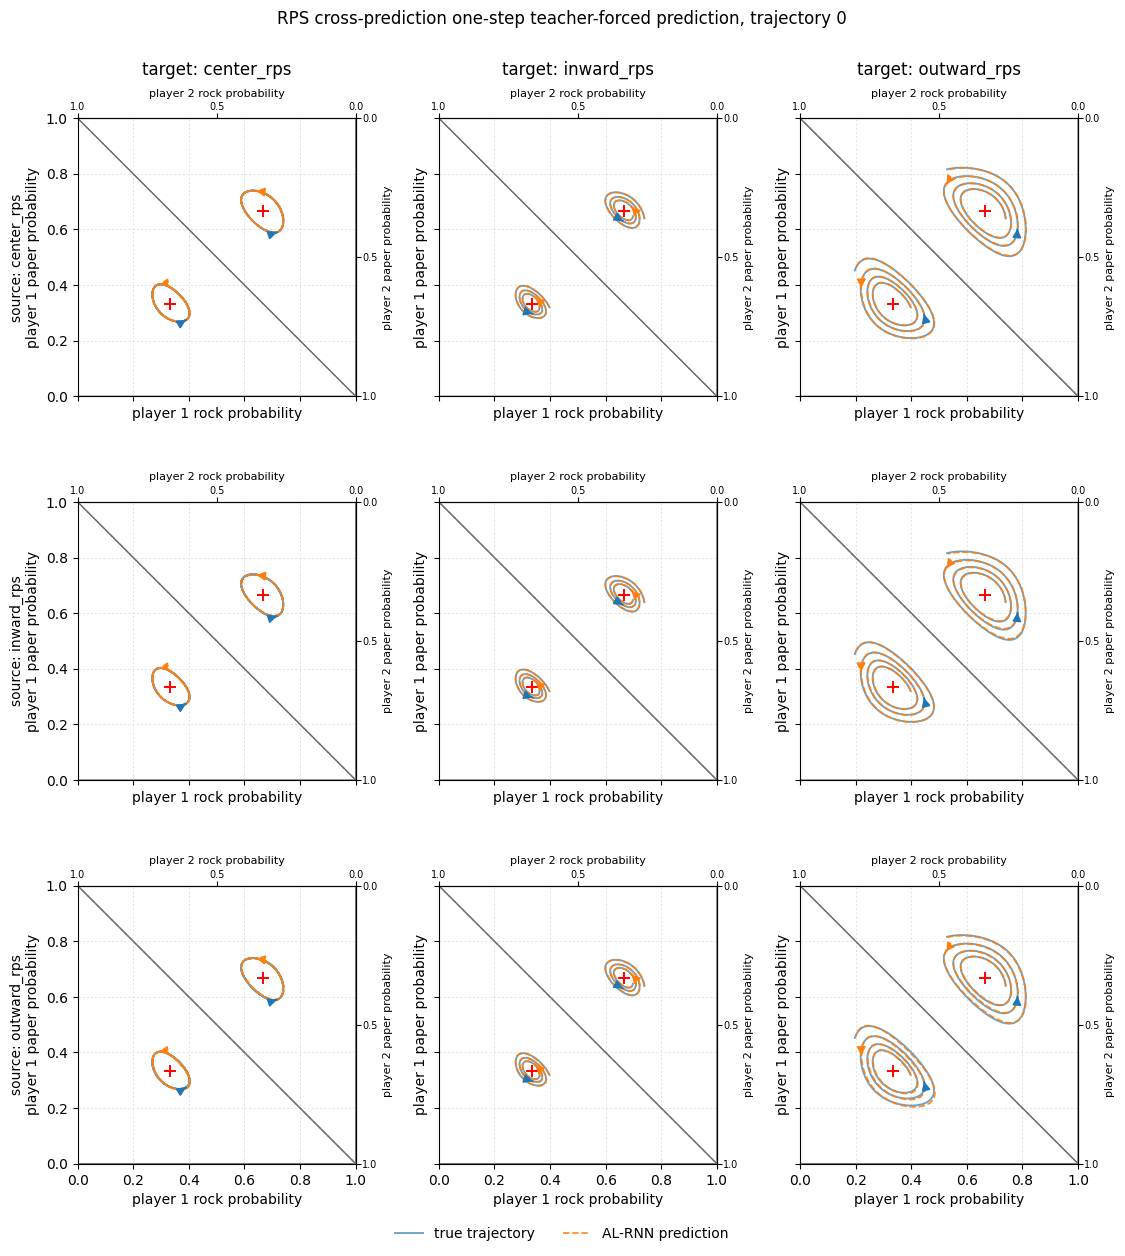

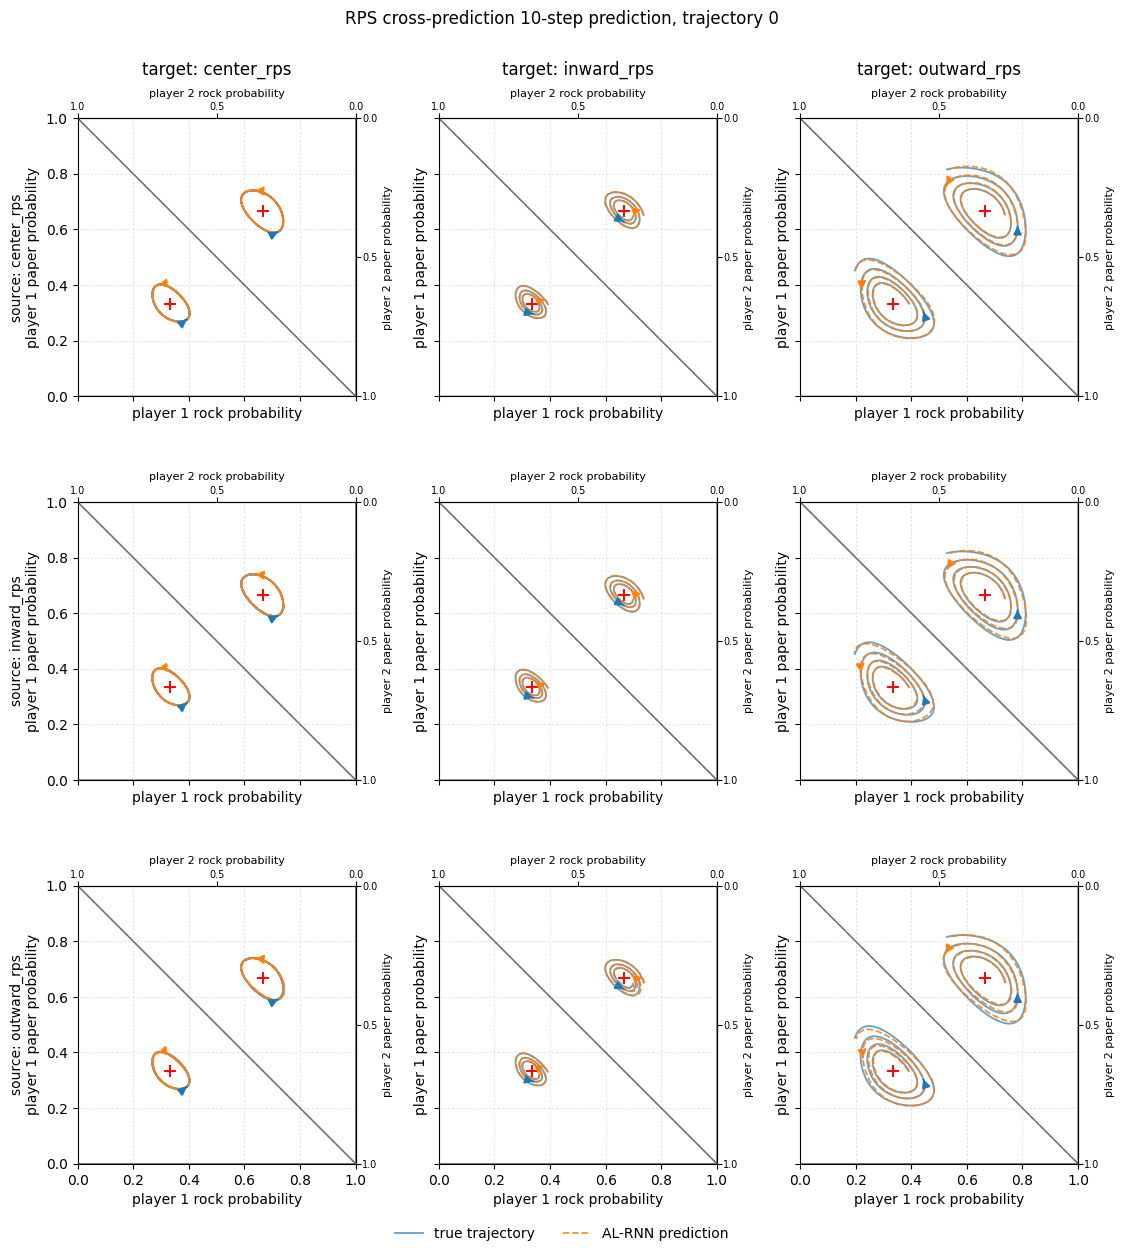

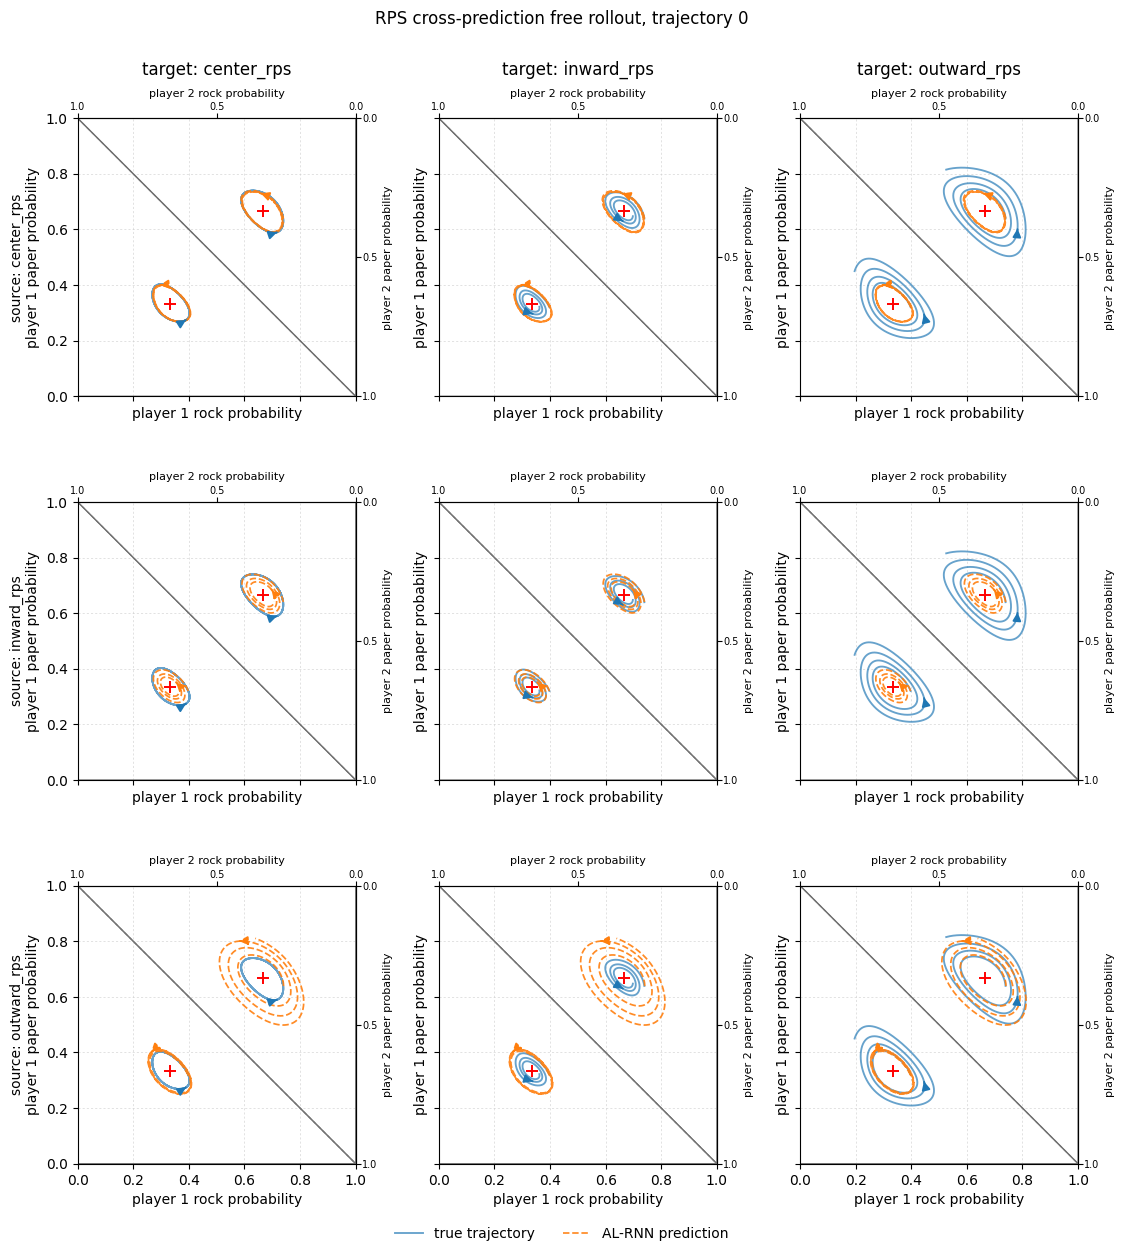

In [47]:
def rps4d_to_full_policy(obs_4d):
    obs_4d = np.asarray(obs_4d)
    policy = np.empty(obs_4d.shape[:-1] + (6,), dtype=obs_4d.dtype)
    policy[..., 0] = obs_4d[..., 0] + 1 / 3
    policy[..., 1] = obs_4d[..., 1] + 1 / 3
    policy[..., 2] = 1.0 - policy[..., 0] - policy[..., 1]
    policy[..., 3] = obs_4d[..., 2] + 1 / 3
    policy[..., 4] = obs_4d[..., 3] + 1 / 3
    policy[..., 5] = 1.0 - policy[..., 3] - policy[..., 4]
    return policy


def add_trajectory_arrow(ax, xy, color, position=0.65, linestyle="-", scale=13):
    xy = np.asarray(xy)
    finite = np.isfinite(xy).all(axis=1)
    xy = xy[finite]
    if len(xy) < 3:
        return

    idx = int(np.clip(position * (len(xy) - 2), 0, len(xy) - 2))
    start = xy[idx]
    end = xy[idx + 1]
    if np.linalg.norm(end - start) <= 1e-12:
        return

    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={
            "arrowstyle": "-|>",
            "color": color,
            "lw": 1.4,
            "linestyle": linestyle,
            "mutation_scale": scale,
            "shrinkA": 0,
            "shrinkB": 0,
        },
        zorder=6,
    )


def plot_rps_simplex_axes(ax):
    ticks = np.arange(0, 1.01, 0.2)

    ax.plot([0, 1, 0, 0], [0, 0, 1, 0], color="0.45", linewidth=0.9)
    ax.plot([1, 0, 1, 1], [1, 1, 0, 1], color="0.45", linewidth=0.9)
    ax.plot([0, 1], [1, 0], linestyle=(0, (3, 3)), color="0.45", linewidth=0.8)

    ax.scatter(1 / 3, 1 / 3, marker="+", s=70, color="red", linewidth=1.4, zorder=5)
    ax.scatter(2 / 3, 2 / 3, marker="+", s=70, color="red", linewidth=1.4, zorder=5)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linestyle=(0, (3, 3)), linewidth=0.5, color="0.8", alpha=0.8)


def plot_rps_cross_prediction_simplex_grid(mode, trajectory_idx=0, max_steps=1000, n_step=10):
    sources = list(RPS_CROSS_MODELS.keys())
    targets = RPS_CROSS_TARGETS
    mode_titles = {
        "free_rollout": "free rollout",
        "one_step": "one-step teacher-forced prediction",
        "n_step": f"{n_step}-step prediction",
    }

    fig, axes = plt.subplots(
        len(sources),
        len(targets),
        figsize=(4.35 * len(targets), 4.25 * len(sources)),
        sharex=True,
        sharey=True,
    )

    for i, source_regime in enumerate(sources):
        for j, target_regime in enumerate(targets):
            ax = axes[i, j]
            true_4d, pred_4d = cross_prediction_pair(
                source_regime,
                target_regime,
                mode=mode,
                trajectory_idx=trajectory_idx,
                max_steps=max_steps,
                n_step=n_step,
            )

            true_full = rps4d_to_full_policy(true_4d)
            pred_full = rps4d_to_full_policy(pred_4d)
            true_p1 = np.column_stack([true_full[:, 0], true_full[:, 1]])
            true_p2 = np.column_stack([1.0 - true_full[:, 3], 1.0 - true_full[:, 4]])
            pred_p1 = np.column_stack([pred_full[:, 0], pred_full[:, 1]])
            pred_p2 = np.column_stack([1.0 - pred_full[:, 3], 1.0 - pred_full[:, 4]])

            plot_rps_simplex_axes(ax)
            ax.plot(true_p1[:, 0], true_p1[:, 1], color="C0", linewidth=1.35, alpha=0.68, label="true trajectory")
            ax.plot(true_p2[:, 0], true_p2[:, 1], color="C0", linewidth=1.35, alpha=0.68)
            ax.plot(pred_p1[:, 0], pred_p1[:, 1], color="C1", linestyle="--", linewidth=1.25, alpha=0.9, label="AL-RNN prediction")
            ax.plot(pred_p2[:, 0], pred_p2[:, 1], color="C1", linestyle="--", linewidth=1.25, alpha=0.9)

            add_trajectory_arrow(ax, true_p1, color="C0", position=0.58, linestyle="-", scale=12)
            add_trajectory_arrow(ax, pred_p1, color="C1", position=0.72, linestyle="--", scale=12)
            add_trajectory_arrow(ax, true_p2, color="C0", position=0.58, linestyle="-", scale=12)
            add_trajectory_arrow(ax, pred_p2, color="C1", position=0.72, linestyle="--", scale=12)

            if i == 0:
                ax.set_title(f"target: {target_regime}", pad=10)
            if j == 0:
                ax.set_ylabel(f"source: {source_regime}\nplayer 1 paper probability")
            else:
                ax.set_ylabel("player 1 paper probability")
            ax.set_xlabel("player 1 rock probability")

            secax_x = ax.secondary_xaxis("top", functions=(lambda x: 1.0 - x, lambda x: 1.0 - x))
            secax_y = ax.secondary_yaxis("right", functions=(lambda y: 1.0 - y, lambda y: 1.0 - y))
            secax_x.set_xticks([0, 0.5, 1.0])
            secax_y.set_yticks([0, 0.5, 1.0])
            secax_x.tick_params(labelsize=7, pad=1)
            secax_x.set_xlabel("player 2 rock probability", fontsize=8, labelpad=4)
            secax_y.set_ylabel("player 2 paper probability", fontsize=8, labelpad=4)
            secax_y.tick_params(labelsize=7, pad=1)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.suptitle(f"RPS cross-prediction {mode_titles[mode]}, trajectory {trajectory_idx}", y=0.985)
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.01))
    fig.subplots_adjust(top=0.90, bottom=0.08, hspace=0.38, wspace=0.25)
    plt.show()


assert_cross_rollout_target_alignment(rps_cross_rollouts, trajectory_idx=0, max_steps=RPS_CROSS_STEPS)
plot_rps_cross_prediction_simplex_grid("one_step", trajectory_idx=0, max_steps=RPS_CROSS_STEPS)
plot_rps_cross_prediction_simplex_grid("n_step", trajectory_idx=0, max_steps=RPS_CROSS_STEPS, n_step=RPS_CROSS_PREDICTION_HORIZON)
plot_rps_cross_prediction_simplex_grid("free_rollout", trajectory_idx=0, max_steps=RPS_CROSS_STEPS)


Next, we extract and align the true trajectories and model predicted trajectories from the completed RPS cross-prediction results to plot the phase portraits.

The one-step prediction plot shows that the true trajectories and the ALRNN predictions overlap almost perfectly. This is because the one-step prediction employs a "teacher-forcing" mechanism: at each time step, the model receives the true current state $x_t$ and predicts only the next state $x_{t+1}$. Consequently, the model is consistently evaluated in states close to the true trajectory manifold. This high degree of overlap indicates that the local vector fields of the three RPS mechanisms are sufficiently similar, enabling the model to transfer short-term predictions across different regimes.

The $n=10$-step prediction plot provides more substantial information than the one-step predictions, yet they still retain a partial "teacher-forcing" component. Starting from a true state, this process requires the model to forecast the trajectory for the next $n$ steps. As observed from the phase portraits, the $n=10$-step prediction curves manage to stay close to the true trajectories, demonstrating that the local dynamics learned by the model remain stable within short time scales.

The free rollout plot illustrates the most challenging test scenario. The model is only initialized from the target trajectory and then evolves autonomously. Here, the prediction is governed entirely by the source model’s learned dynamics. Therefore, for a fixed source model and matched initial conditions, the predicted trajectory can look similar across different target regimes. This reflects the fact that the learned autonomous system is not conditioned on the target regime. It simply applies the source regime’s dynamics from the same initial state.

The phase portraits show that while the ALRNN effectively captures local dynamics, its long-term behavior is determined by the source mechanism. This explains why the model performs well in one-step and $n=10$-step predictions but fails in cross-mechanism free rollout scenarios.